# Unscented Kalman Filter Implementation on Quadrotor Data

In [1]:
import torch
import torch.optim
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import copy
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
from torch.distributions import Normal, Independent, kl_divergence
from collections import namedtuple
from math import e, cos, sin, pi, atan2, asin, sqrt, tan

In [2]:
class Quadrotor_Dynamics_Generator():

  def __init__(self,
               x_size=23,
               y_size=12,
               traj_length=2,
               normalize=True,
               xy_offset=20,
               min_Z=0,
               max_Z=50,
               xydot_offset=60.0,
               min_Zdot = -30,
               max_Zdot = 30,
               min_accel_xy = -50,
               max_accel_xy = 50,
               min_accel_z = -50,
               max_accel_z = 50, 
               min_omega=-80,
               max_omega=80,
               min_omegadot=-80,
               max_omegadot=80,
               min_rp = -pi/2 + 0.1,
               max_rp = pi/2 - 0.1,
               min_rotor_rps = 0,
               max_rotor_rps = 1000,
               perturb_rps=10,
               ground_effect=False,
               Z_thresh=2,
               quad_mass=20,
               device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
              ):

    self.device = device
    self.x_size = x_size
    self.y_size = y_size
    self.traj_length = traj_length
    self.normalize = normalize
    self.xy_offset = xy_offset
    self.min_Z = min_Z
    self.max_Z = max_Z
    self.xydot_offset = xydot_offset

    self.min_rp = min_rp
    self.max_rp = max_rp
    self.min_rotor_bound = min_rotor_rps
    self.max_rotor_bound = max_rotor_rps
    self.perturb_rps = perturb_rps
    self.ground_effect = ground_effect
    self.Z_thresh = Z_thresh
    self.m = quad_mass
    self.constants = self.constants_init()

    # Initialize minmax data needed for relavent simulation parameters
    self.minmax_data = torch.tensor([[-self.xydot_offset, self.xydot_offset],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [min_Zdot, max_Zdot],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_z, max_accel_z],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [0, 0], #dt
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [min_rotor_rps, max_rotor_rps],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [0, 0],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [-self.xydot_offset, self.xydot_offset],
                                    [min_Zdot, max_Zdot],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_xy, max_accel_xy],
                                    [min_accel_z, max_accel_z],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omega, max_omega],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot],
                                    [min_omegadot, max_omegadot]])
    

  # Evolves the dynamics of quadrotor
  def eqn_mtn(self, state_vec, uu, dt, V_w, rotor_disturbances=False, rotor_spike_bound=100, linvel_offset=torch.zeros([3,]), angvel_offset=torch.zeros([3,])):

    ########     NESTED FUNCTION     ########

    # Verify boundness of Euler angles
    def theta_check(theta):
      # Parsing euler angles
      roll = theta[0]
      pitch = theta[1]
      yaw = theta[2]

      # Ensuring euler angles remain within [-pi, pi]
      roll_offset = torch.abs(torch.floor(roll / (2*pi)))
      pitch_offset = torch.abs(torch.floor(pitch / (2*pi)))
      yaw_offset = torch.abs(torch.floor(yaw / (2*pi)))

      if roll > pi:
        roll -= roll_offset * (2*pi)
      elif roll < -pi:
        roll += roll_offset * (2*pi)

      if pitch > pi:
        pitch -= pitch_offset * (2*pi)
      elif pitch < -pi:
        pitch += pitch_offset * (2*pi)

      if yaw > pi:
        yaw -= yaw_offset * (2*pi)
      elif yaw < -pi:
        yaw += yaw_offset * (2*pi)

      theta_transformed = torch.tensor([roll, pitch, yaw], device=self.device)
      return theta_transformed
    
    ###########   END OF NESTED FUNCTION   ###########
    
    # Parsing positional and velocity states
    x = state_vec[:3]
    theta = state_vec[3:6]
    xdot = state_vec[6:9]
    thetadot = state_vec[9:12]
    omega = state_vec[12:15]
    omegadot = state_vec[15:18]
    a = state_vec[18:]
    
    # Checking if current altitude is at ground effect threshold  
    if x[2] <= 2 and x[2] > 0:
      self.ground_effect = True
    else:
      self.ground_effect = False  
      
   # print(f'EQN_MTN BEFORE: xdot_prev: {xdot}, a: {a}, omega_prev: {omega}, omegadot: {omegadot}')

    # Initializing needed constants
    I = self.constants['I']
    I_r = self.constants['I_r']
    g = self.constants['g']
    m = self.constants['m']
    L = self.constants['L']
    b = self.constants['b']
    kf = self.constants['kf']
    km = self.constants['km']
    kd = self.constants['kd']
    d_array = self.constants['d_array']

    # Incorporating rotor spiking (if applicable)
    if rotor_disturbances == True:
      uu_observed = uu.clone()
      uu = self.perturb_rv(uu_observed, rotor_spike_bound=rotor_spike_bound)

    # Integrating body rates
    omega = omega + dt * omegadot

    # Ensuring commanded velocities keep quadrotor within defined state space
    if linvel_offset.any():
      xdot = linvel_offset
    else:
      xdot = xdot + dt * a
      
    if angvel_offset.any():
      thetadot = angvel_offset
    else: 
      thetadot = self.omega2thetadot(omega, theta)

    # Integrating positional states
    theta = theta + dt * thetadot
    x = x + dt * xdot

    # Ensuring euler angles lie within appropriate bounds
    theta = theta_check(theta)
    
    # Transforming inputs into $\omega_{i}^2$
    uu = torch.pow(uu, 2)

    # Computing quadrotor body rates from updated euler data
    omega = self.thetadot2omega(thetadot, theta)
    
    # Computing forces and moments from external perturbations
    V_w, F_w = self.inject_wind_peturb(V_w, dt)
    Vr_array = self.compute_rotor_linvels(xdot, theta, omega, d_array, V_w)
    F_bf, F_bf_array = self.inject_blade_flapping_force(theta, uu, Vr_array)
    F_id, F_id_array = self.inject_induced_drag_force(theta, uu, Vr_array)
    
    if self.ground_effect: 
      Fg = self.inject_ground_effect(z=x[2],z_thresh=2)
    else:
      Fg = torch.zeros_like(F_bf, device=self.device)

    # Computing exogenous disturbances
    F_aero = F_bf + F_id + Fg + F_w
    tau_aero = self.inject_torque_perturb(F_bf_array, F_id_array, d_array)
    
    # Compute linear and angular accelerations.
    a = self.acceleration(uu, theta, xdot, m, g, kf, kd, F_aero, prev_a=a)
    omegadot = self.angular_acceleration(uu, omega, I, I_r, L, b, km, tau_aero, prev_ωdot=omegadot)

    # Updating state vector
    state_vec = torch.concat([x, theta, xdot, thetadot, omega, omegadot, a], dim=0)
    #print(f'EQN_MTN AFTER: xdot_prev: {xdot}, a: {a}, omega_prev: {omega}, omegadot: {omegadot}, V_w: {V_w}')
    
    return state_vec, V_w, F_aero, tau_aero
  
  ####   QUADROTOR PHYSICS FUNCTIONS   ####
  
  # Compute translational accelerations
  def acceleration(self, inputs, angles, xdot, m, g, kf, kd, F_aero, prev_a=torch.zeros([3,])):
    gravity = torch.tensor([0,0,-g], device=self.device)
    R = self.rotation(angles)
    T = R @ self.thrust(inputs, kf)
    Fd = -kd * xdot
    a = gravity + (1/m) * (T + Fd + F_aero) - kd * prev_a.to(self.device)
    return a

  # Compute angular accelerations
  def angular_acceleration(self, inputs, omega, I, I_r, L, b, km, tau_aero, prev_ωdot=torch.zeros([3,])):
    tau_m = self.motor_torques(inputs, L, b, km)
    tau_g = self.gyroscopic_torques(inputs, omega, I_r)
    
    #print(f'tau_m: {tau_m}, tau_aero: {tau_aero}, tau_g: {tau_g}\n')
    tau = (tau_m + tau_aero - tau_g)
    omegadot = torch.inverse(I) @ (tau - torch.linalg.cross(omega, I @ omega)) - km * prev_ωdot.to(self.device)
    return omegadot
  
  # Compute torques, given current inputs, length of arm, drag coefficient, and moment coefficient.
  def motor_torques(self, inputs, L, b, km):
    # Inputs are values for ${\omega_i}^2$
    tau = torch.tensor([
        L * km * (inputs[0] - inputs[2]),
        L * km * (inputs[1] - inputs[3]),
        b * (inputs[0] - inputs[1] + inputs[2] - inputs[3])
    ], device=self.device)
    return tau
  
  # Compute thrust given current inputs and thrust coefficient.
  def thrust(self, inputs, kf):
    # Inputs are values for ${\omega_i}^2$
    T = torch.tensor([0, 0, kf * torch.sum(inputs)], device=self.device)
    return T

  # Compute gyroscopic torques on quadrotor
  def gyroscopic_torques(self, inputs, omega, I_r):
    # Parsing body rates
    pp = omega[0]
    qq = omega[1]
    
    # Untransforming squared inputs
    inputs = torch.sqrt(inputs)
    
    # Computing gyroscopic torques
    tau_g = torch.zeros([3,], device=self.device)
    tau_g[0] = I_r*qq*(inputs[0] - inputs[1] + inputs[2] - inputs[3])
    tau_g[1] = -I_r*pp*(inputs[0] - inputs[1] + inputs[2] - inputs[3])
    
    return tau_g

  ####    END OF PHYSICS FUNCTIONS     ####


  ####  PERTURBATION/NOISE FUNCTIONS   ####

  def perturb_rv(self, uu, rotor_spike_bound=100):

    # High: perturb_rps minmax = -100, 100
    # Medium: perturb_rps_minmax = -50, 50

    max_rotor_perturb_rps = rotor_spike_bound
    min_rotor_perturb_rps = -rotor_spike_bound
    
    # Sampling rotor spiking values
    dω1 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω2 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω3 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    dω4 = random.random() * (max_rotor_perturb_rps - min_rotor_perturb_rps) + min_rotor_perturb_rps
    
    # Applying spiking values to rotor velocities
    uu[0] += dω1
    uu[1] += dω2
    uu[2] += dω3
    uu[3] += dω4

     # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20
    
    return uu
  
  def model_rotor_vels(self, uu, noise_bias=10, noise_std=15):
    
    # Sampling noise vector to perturb rotor velocities in realistic manner
    noise_uu = torch.normal(mean=torch.tensor(noise_bias), std=torch.tensor(noise_std), size=[4,])
    
    # Applying noise to rotor velocities
    uu += noise_uu
    
    # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20
    
    # Applying quantization step
    uu = torch.round(uu)
    
    return uu


  def compute_rotor_linvels(self, xdot, theta, omega, d_array, V_w):
    # VECTORIZE
    
    # Computing rotation matrix for  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing rotor linear velocities for each rotor
    Vr_array = torch.zeros([4,3], device=self.device)
    for rotor in range(4):
      Vr_array[rotor,:] = R.T @ (xdot - V_w) + torch.linalg.cross(omega, d_array[rotor,:])
    
    return Vr_array
    

  def inject_blade_flapping_force(self, theta, uu, Vr_array):
    # VECTORIZE
    
    # Defining needed aerodynamic coefficients
    Ct = 2e-3
    Ca = 5e-4
    Cb = 5e-4

    # Computing rotation matrix  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing sum of blade flapping forces coming from all rotors
    F_bf = torch.zeros([3,])
    F_bf_array = torch.zeros([4,3])
    mat = torch.tensor([[Ca,-Cb,0],
                        [Cb,Ca,0],
                        [0,0,0]])
    
    for rotor in range(uu.shape[0]):
      rotor_F_bf = -Ct * uu[rotor] * R @ mat @ Vr_array[rotor,:]
      F_bf += rotor_F_bf
      F_bf_array[rotor,:] = rotor_F_bf

    return F_bf, F_bf_array

  def inject_induced_drag_force(self, theta, uu, Vr_array):
    # VECTORIZE
    # Defining needed aerodynamic coefficients
    Ct = 2e-3
    Cdx = 5e-4
    Cdy = 5e-4

    # Computing rotation matrix  (Body -> Inertial)
    R = self.rotation(theta)

    # Computing sum of induced drag forces from all rotors
    F_id = torch.zeros(3,)
    F_id_array = torch.zeros([4,3]) 
    mat = torch.tensor([[Cdx,0,0],
                        [0,Cdy,0],
                        [0,0,0]])
    
    for rotor in range(uu.shape[0]):
      rotor_F_id = -Ct * uu[rotor] * R @ mat @ Vr_array[rotor,:]
      F_id += rotor_F_id
      F_id_array[rotor,:] = rotor_F_id

    return F_id, F_id_array
  
  def inject_ground_effect(self, z, z_thresh):
  
    # Defining needed aerodynamic coefficient
    Cg = 1e-3

    # Computing ground effect force
    Fg_coeff = Cg / (4*z**2) - Cg / (z_thresh - z) ** 2
    Fg = Fg_coeff * torch.tensor([0,0,1])
    
    # Computing maximum allowed ground effect force based on quadrotor weight
    Fg_max = 0.4 * (self.m * 9.8)
    
    # Constraining ground effect force to be within realistic bounds
    if Fg[2] > Fg_max:
      Fg[2] = Fg_max
    elif Fg[2] < -Fg_max:
      Fg[2] = -Fg_max

    return Fg


  def inject_torque_perturb(self, F_bf_array, F_id_array, d_array):
    # VECTORIZE
    def skew_symmetric(d):
      Sd = torch.tensor([[0,-d[2],d[1]],
                        [d[2],0,-d[0]],
                        [-d[1],d[0],0]])
      return Sd

    tau_perturb = torch.zeros([3,])
    for rotor in range(4):
      d = d_array[rotor,:]
      F_bf = F_bf_array[rotor,:]
      F_id = F_id_array[rotor,:] 

      Sd = skew_symmetric(d)

      tau_perturb += Sd @ (F_bf + F_id)
    
    return tau_perturb
  
  def inject_wind_peturb(self, V_w, dt):
  
    # Computing matrices needed for wind update
    w_array1 = torch.tensor([80,75,24], dtype=torch.float32)
    w_array1 = torch.diag(w_array1)

    w_array2 = torch.tensor([1.65,1.5,1.9])
    w_array2 = torch.inverse(torch.diag(w_array2))

    # Computing updated wind force
    F_w = torch.tensor([
                    0.05 * V_w[0]**2 * torch.sign(V_w[0]), 
                    0.05 * V_w[1]**2 * torch.sign(V_w[1]),
                    0.1 * V_w[2]**2 * torch.sign(V_w[2])
                  ])

    # Computing updated wind velocity
    w_d = torch.normal(mean=0, std=0.2, size=[3,])
    V_wdot = w_array2 @ (-V_w + w_array1 @ w_d)

    V_w += V_wdot * dt
    
    return V_w, F_w
  

  def apply_mm_gaussian_noise(self, xdot, a, ω, ωdot, max_num_peaks=5, num_points=500, gps_err_bias1=5e-2, gps_err_std1=1e-2, gyro_err_bias1=1e-2, gyro_err_std1=5e-2, 
                              gps_err_bias2=5e-1, gps_err_std2=6e-1, gyro_err_bias2=5e-1, gyro_err_std2=1.0, max_motion_scale=6e-3, min_motion_scale=5e-4):

    # Large Noise: gps_err_bias=0.2, gps_err_std=0.6, gyro_err_bias=5e-1, gyro_err_std=1e-3
    # Medium Noise: gps_err_bias=5e-2, gps_err_std=6e-3, gyro_err_bias=1e-2, gyro_err_std=1e-3

    # Preventing in-place computations
    xdot = xdot.clone()
    a = a.clone()
    ω = ω.clone()
    ωdot = ωdot.clone()
  
    num_peaks = random.randint(2,max_num_peaks)
    peak_weights = torch.rand([num_peaks,])
    peak_weights /= torch.sum(peak_weights)

    for i in range(num_peaks):
      
      # Computing sample size for noise peak
      N = int(torch.ceil(num_points * peak_weights[i])) if int(torch.ceil(num_points * peak_weights[i])) > 3 else 3

      # Sampling sensor noise characteristics
      gps_err_bias = random.random() * (gps_err_bias2 - gps_err_bias1) + gps_err_bias1
      gps_err_std = random.random() * (gps_err_std2 - gps_err_std1) + gps_err_std1
      gyro_err_bias = random.random() * (gyro_err_bias2 - gyro_err_bias1) + gyro_err_bias1
      gyro_err_std = random.random() * (gyro_err_std2 - gyro_err_std1) + gyro_err_std1

      # Instantiating zero-mean gaussian noise for translational and angular data
      noise_xdot = torch.normal(mean=torch.tensor(gps_err_bias), std=torch.tensor(gps_err_std), size=[N,])
      noise_a = torch.normal(mean=torch.tensor(gps_err_bias*1.5), std=torch.tensor(gps_err_std*1.5), size=[N,])
      noise_ω = torch.normal(mean=torch.tensor(gyro_err_bias), std=torch.tensor(gyro_err_std), size=[N,])
      noise_ωdot = torch.normal(mean=torch.tensor(gyro_err_bias*1.5), std=torch.tensor(gyro_err_std*1.5), size=[N,])

      # Shuffle the elements of the multimodal distribution
      shuffled_dist_xdot = noise_xdot[torch.randperm(len(noise_xdot))]
      shuffled_dist_a = noise_a[torch.randperm(len(noise_a))]
      shuffled_dist_ω = noise_ω[torch.randperm(len(noise_ω))]
      shuffled_dist_ωdot = noise_ωdot[torch.randperm(len(noise_ωdot))]

      # Parsing multimodal gaussian noise to disrupt sensor data
      noise_xdot = shuffled_dist_xdot[torch.randperm(3)]
      noise_a = shuffled_dist_a[torch.randperm(3)]
      noise_ω = shuffled_dist_ω[torch.randperm(3)]
      noise_ωdot = shuffled_dist_ωdot[torch.randperm(3)]


    # Applying additive/multiplicative noise to dynamic signals
    motion_scale = random.random() * (max_motion_scale - min_motion_scale) + min_motion_scale
    xdot += noise_xdot
    a += noise_a
    ω += noise_ω
    ωdot += noise_ωdot
    
    xdot *= (1 + motion_scale * xdot)
    a *= (1 + motion_scale * a)
    ω *= (1 + motion_scale * ω)
    ωdot *= (1 + motion_scale * ωdot)

    return xdot, a, ω, ωdot
  
  ####   END OF PERTURBATION/NOISE FUNCTIONS    ####
  
  # Initializing needed constants for simulation
  def constants_init(self):
      # Move constants to the specified device (GPU or CPU)
      m = torch.tensor([self.m], device=self.device)                            # Mass of quadrotor (kg)
      g = torch.tensor(9.806, device=self.device)                               # Gravitational force (m/s^2)
      L = torch.pow((m / 2.5), 1/3)                                        # Length of quadrotor arm (rotor-to-center) (m)
      r_prop = L / 4                                                      # Radius of quadrotor propellor
      A = torch.pi * r_prop**2                                             # Cross-sectional area of propellor

      # Defining inertia tensor of quadrotor (kg*m^2)
      I = torch.zeros([3, 3], device=self.device)
      I[0, 0] = 0.35 * m
      I[1, 1] = 0.35 * m
      I[2, 2] = 0.40 * m

      # Defining rotor inertia (kg*m^2)
      I_r = 4e-5 * self.m * L**2

      # Defining quadrotor aerodynamic properties
      force_reg = torch.tensor(1e-3, device=self.device)
      torque_reg = torch.tensor(5e-4, device=self.device)
      rho = torch.tensor(1.225, device=self.device)                             # Air density (kg/m^3)
      ω_hover = torch.sqrt((m * g) / (4 * 1e-3))                           # Angular velocity of rotors needed to hover (rad/s)
      km = (2.5 * m * g) / (4 * ω_hover**2) * torque_reg                  # Aerodynamic moment coefficient (N*s^2)
      kf = 5e-3 * force_reg * m                                            # Aerodynamic force coefficient (N*s^2)
      C_d = torch.tensor(1.5, device=self.device)                               # Aerodynamic drag coefficient

      # Translational and moment drag coefficient
      kd = 0.5 * rho * C_d * A
      b = 0.5 * r_prop**3 * rho * C_d * A * torque_reg

      # Defining individual rotor distances to quadrotor center of mass
      d_array = torch.zeros([4, 3], device=self.device)
      rotor_angle = torch.tensor([torch.pi/4, 3*torch.pi/4, 5*torch.pi/4, 7*torch.pi/4], device=self.device)
      for rotor in range(d_array.shape[0]):
          d_array[rotor, 0] = L * torch.sin(rotor_angle[rotor])
          d_array[rotor, 1] = L * torch.cos(rotor_angle[rotor])
          d_array[rotor, 2] = 0.2 * L

      # Updating internal quadrotor inertial properties
      constants = {'I': I, 'I_r': I_r, 'g': g, 'm': m, 'L': L, 'b': b, 'kf': kf, 'km': km, 'kd': kd, 'd_array': d_array}
      return constants



  # Computing ZYZ rotation matrix (Body -> Inertial)
  def rotation(self, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]
    yaw = theta[2]

    # Computing rotation matrix
    R = torch.tensor([[cos(roll)*cos(yaw) - cos(pitch)*sin(roll)*sin(yaw), -cos(yaw)*sin(roll) - cos(roll)*cos(pitch)*sin(yaw), sin(pitch)*sin(yaw)],
                      [cos(pitch)*cos(yaw)*sin(roll) + cos(roll)*sin(yaw), cos(roll)*cos(pitch)*cos(yaw) - sin(roll)*sin(yaw), -cos(yaw)*sin(pitch)],
                      [sin(roll)*sin(pitch), cos(roll)*sin(pitch), cos(pitch)]])

    return R

  def linvel_control(self, Z):
    # Applying appropriate translational velocity offsets based on
    # quadrotor's current pose outside of defined regions (in m/s)
    linvel_offset = torch.zeros([3,])
  
    # Altitude control.
    if Z > self.max_Z:
      linvel_offset[2] = -10
    elif Z < self.min_Z:
      linvel_offset[2] = 10

    return linvel_offset


  def roll_pitch_control(self, ROLL, PITCH):
    # Applying appropriate roll/pitch velocity offset based on
    # quadrotor's current attitude (in rad/s)
    euler_offset = torch.zeros([3,])

    if ROLL < self.min_rp:
      euler_offset[0] = pi/2
    elif ROLL > self.max_rp:
      euler_offset[0] = -(pi/2)

    if PITCH < self.min_rp:
      euler_offset[1] = pi/2
    elif PITCH > self.max_rp:
      euler_offset[1] = -(pi/2)

    return euler_offset
  

  def sample_quad_states(self, uu, rollpitch_bounds=pi/2,yaw_bounds=pi,linvel_bounds=10,angvel_bounds=4*pi,windvel_bounds=20):
    # Sample random initial simulation states
    X = random.random() * (self.xy_offset + self.xy_offset) - self.xy_offset
    Y = random.random() * (self.xy_offset + self.xy_offset) - self.xy_offset
    Z = random.random() * (self.max_Z - self.min_Z) + self.min_Z
    x = torch.tensor([X, Y, Z], device=self.device)
    
    # Ground effect check
    if Z <= self.Z_thresh:
      self.ground_effect=True
    else:
      self.ground_effect=False

    ROLL = random.random() * (rollpitch_bounds + rollpitch_bounds) - rollpitch_bounds
    PITCH = random.random() * (rollpitch_bounds + rollpitch_bounds) - rollpitch_bounds
    YAW = random.random() * (yaw_bounds + yaw_bounds) - yaw_bounds
    theta = torch.tensor([ROLL, PITCH, YAW], device=self.device)

    X_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    Y_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    Z_dot = random.random() * (linvel_bounds + linvel_bounds) - linvel_bounds
    xdot = torch.tensor([X_dot, Y_dot, Z_dot], device=self.device)

    ROLL_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    PITCH_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    YAW_dot = random.random() * (angvel_bounds + angvel_bounds) - angvel_bounds
    thetadot = torch.tensor([ROLL_dot, PITCH_dot, YAW_dot], device=self.device)

    # Initializing needed constants
    I = self.constants['I']
    I_r = self.constants['I_r']
    g = self.constants['g']
    m = self.constants['m']
    L = self.constants['L']
    b = self.constants['b']
    kf = self.constants['kf']
    km = self.constants['km']
    kd = self.constants['kd']
    d_array = self.constants['d_array']

    # Transforming inputs into $\omega_{i}^2$
    uu = torch.pow(uu, 2)

    # Computing quadrotor body rates
    omega = self.thetadot2omega(thetadot, theta)

    # Computing forces and moments from external perturbations
    V_w = torch.zeros([3,])
    V_w[0] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds
    V_w[1] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds
    V_w[2] = random.random() * (windvel_bounds + windvel_bounds) - windvel_bounds

    F_w = torch.tensor([
                    0.05 * V_w[0]**2 * torch.sign(V_w[0]), 
                    0.05 * V_w[1]**2 * torch.sign(V_w[1]),
                    0.1 * V_w[2]**2 * torch.sign(V_w[2])
    ], device=self.device)
    
    Vr_array = self.compute_rotor_linvels(xdot, theta, omega, d_array, V_w)
    F_bf, F_bf_array = self.inject_blade_flapping_force(theta, uu, Vr_array)
    F_id, F_id_array = self.inject_induced_drag_force(theta, uu, Vr_array)
    
    if self.ground_effect: 
      Fg = self.inject_ground_effect(Z,self.Z_thresh)
    else:
      Fg = torch.zeros_like(F_bf)

    F_aero = F_bf + F_id + Fg + F_w
    tau_aero = self.inject_torque_perturb(F_bf_array, F_id_array, d_array)
    
    # Computing translational+rotational accelerations from sampled states
    a = self.acceleration(uu, theta, xdot, m, g, kf, kd, F_aero)
    omegadot = self.angular_acceleration(uu, omega, I, I_r, L, b, km, tau_aero)
   # print(f'(sampled accel): {a}, omegadot: {omegadot}\n')

    # Saving randomized states into state vector
    state_vec = torch.concat([x, theta, xdot, thetadot, omega, omegadot, a], dim=0)

    return state_vec, V_w


  def state_space_verify(self, Z, ROLL, PITCH):
    # Boolean that checks if quadrotor's states are within defined state space
    state_verified = False

    if Z > self.min_Z and abs(ROLL) < self.max_rp and abs(PITCH) < self.max_rp:

      state_verified = True

    return state_verified
  
  def quad_vel_verify(self, prev_state_vec, next_state_vec, linvel_offset, pitch_offset):
    vel_verified = True
    xdot_prev = prev_state_vec[6:9]
    thetadot_prev = prev_state_vec[9:12]

    xdot_next = next_state_vec[6:9]
    thetadot_next = next_state_vec[9:12]
    
    # Check to prevent offset velocities being included in 'quadout'
    if (xdot_next == linvel_offset).any() or (xdot_prev == linvel_offset).any() or \
      (thetadot_next == pitch_offset).any() or (thetadot_prev == pitch_offset).any():
        vel_verified = False

    return vel_verified

  def thetadot2omega(self, thetadot, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]

    # Computing rotation matrix (Inertial -> Body)
    R = torch.tensor([[1, 0, -sin(pitch)],
                      [0, cos(roll), cos(pitch)*sin(roll)],
                      [0, -sin(roll), cos(pitch)*cos(roll)]])

    # Computing angular body rates
    omega = R @ thetadot

    return omega


  def omega2thetadot(self, omega, theta):
    # Parsing euler angles
    roll = theta[0]
    pitch = theta[1]

    # Computing rotation matrix (Body -> Inertial)
    R_inv = torch.tensor([[1, sin(roll)*tan(pitch), cos(roll)*tan(pitch)],
                          [0, cos(roll), -sin(roll)],
                          [0, sin(roll)/cos(pitch), cos(roll)/cos(pitch)]])

    # Computing angular body rates
    thetadot = R_inv @ omega

    return thetadot

  
  def update_controls(self, uu, rotor_rps_bound=20):

    # Computing randomly-selected change in each rotor velocity of quadrotor
    dw1 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw2 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw3 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound
    dw4 = random.random() * (rotor_rps_bound + rotor_rps_bound) - rotor_rps_bound

    # Updating rotor velocities
    uu[0] += dw1
    uu[1] += dw2
    uu[2] += dw3
    uu[3] += dw4

    # Applying saturation limits
    for rotor in range(uu.shape[0]):
      if uu[rotor] > self.max_rotor_bound:
        uu[rotor] = self.max_rotor_bound - 20
      elif uu[rotor] < self.min_rotor_bound:
        uu[rotor] = self.min_rotor_bound + 20

    return uu
  
  
  def index_data_stacker(self, dataset, unnorm=False):
    # Parsing relevant data shapes
    num_targets = dataset.shape[0]
    traj_length = dataset.shape[1]
    stack_iters = dataset.shape[2]

    # Initializing index data objects needed for computation
    idx = torch.randperm(num_targets)
    idx = torch.unsqueeze(idx, dim=-1)
    idx_array = torch.tensor([])
    idx_tnsr = torch.zeros([num_targets, traj_length, stack_iters])
    
    # Ensuring idx_array.shape == idx_tnsr[:,:,i].shape 
    for _ in range(traj_length):
      idx_array = torch.concat([idx_array, idx], dim=1)
    idx_array = torch.unsqueeze(idx_array, dim=-1)

    # Updating each dimension of idx_tnsr with idx_array
    for stack in range(stack_iters):
      idx_tnsr[:,:,stack:stack+1] = idx_array
      
    if unnorm:
      idx_tnsr_unnorm = torch.tile(idx_tnsr[:,0,0:1], (1,35))
      return idx_tnsr.to(dtype=torch.int64), idx_tnsr_unnorm.to(dtype=torch.int64)

    return idx_tnsr.to(dtype=torch.int64) # ensure all entries are integers
  
  
  # Minmax normalization function  
  def minmax_norm(self, dataset):
    # Parsing relevant data shapes
    batch_size = dataset.shape[0]
    dynamical_data_dim = dataset.shape[1]

    dim_skips = [12] + list(range(17,23))

    for batch in range(batch_size):
        for dim in range(dynamical_data_dim):
        # Skipping sampling rate dimension to avoid normalization
            if dim in dim_skips:
                continue

            curr_sequence = dataset[batch,dim:dim+1]
            curr_min = self.minmax_data[dim,0]
            curr_max = self.minmax_data[dim,1]

            dataset[batch,dim:dim+1] = (curr_sequence - curr_min) / (curr_max - curr_min)

    return dataset

  # Minmax normalization function (for entire batch)
  def minmax_norm_batch(self, dataset):
    minmax_data = torch.concat([self.minmax_data[:12,:], self.minmax_data[13:17,:]], dim=0)
    curr_min = minmax_data[:dataset.shape[1], 0].unsqueeze(0)  # Shape: (1, state_dim)
    curr_max = minmax_data[:dataset.shape[1], 1].unsqueeze(0)
    normalized = (dataset - curr_min) / (curr_max - curr_min)
    return normalized


  # Minmax unnormalization function
  def minmax_unnorm(self, x_pred, x=torch.tensor([])):
    curr_min = self.minmax_data[:x_pred.shape[1], 0].unsqueeze(0)
    curr_max = self.minmax_data[:x_pred.shape[1], 1].unsqueeze(0)
    x_pred_unnorm = x_pred * (curr_max - curr_min) + curr_min

    if x.numel() > 0:
        x_unnorm = x * (curr_max - curr_min) + curr_min
        return x_pred_unnorm, x_unnorm
    else:
        return x_pred_unnorm
  
  # Convert tensor of shape (N, 2, 35) to (2N, 35)
  def tensor_break(self, traj):
    print('shape of input tensor:', traj.shape)
    updated_quadout = traj.clone()
    combined_quad_array = torch.empty([updated_quadout.shape[0]*2, 35])
    for iter,i in enumerate(range(0, 2*updated_quadout.shape[0], 2)):

        added_inputs1 = updated_quadout[iter:iter+1,0,12:23]
        added_inputs2 = updated_quadout[iter:iter+1,1,12:23]

        traj1 = updated_quadout[iter:iter+1,0,:12]
        traj2 = updated_quadout[iter:iter+1,0,23:]
        traj3 = updated_quadout[iter:iter+1,1,:12]
        traj4 = updated_quadout[iter:iter+1,1,23:]
        array1 = torch.concat([traj1,added_inputs1,traj2], dim=-1)
        array2 = torch.concat([traj3,added_inputs2,traj4], dim=-1)

        traj_array = torch.concat([array1, array2], dim=0)
        combined_quad_array[i:i+2,:] = traj_array

    print('shape of converted tensor:', combined_quad_array.shape)

    return combined_quad_array
  

  def generate_random_signs(self, size):
    # Generate random integers (0 or 1)
    random_ints = torch.randint(0, 2, (size,))
    
    # Map 0 to -1 and 1 to 1
    signs = 2 * random_ints - 1
    
    return signs
  
  def generate_test_traj(self, seq_length, perturb_params, gaussian_noise=True):
    
    # Initializing quadrotor output array
    quadout = torch.zeros([seq_length, self.traj_length, self.x_size+self.y_size], device=self.device)
    
    # Parsing sensor perturb parameters
    rotor_spike_bound = perturb_params[0]
    wind_profile = perturb_params[1]
    V_w = wind_profile * self.generate_random_signs(size=3)
  
    disturb_quad_at = 1
    disturbance_iter = 0
    

    # Initializing input trajectory from our controller.
    w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
    uu = torch.tensor([w1, w2, w3, w4], device=self.device)
      
    # Sampling initial quadrotor states
    state_vec, V_w = self.sample_quad_states(uu)
    
    # Sampling initial sampling rate
    dt = random.random() * (0.2 - 0.0001) + 0.0001

    # Saving current state as previous one
    prev_state_vec = state_vec
    
    for i in range(seq_length):

      while True:
        
        transition_complete = False
        for j in range(self.traj_length):
          
          # Integrating dynamical states
          if disturbance_iter % disturb_quad_at == 0:
            next_state_vec, _, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w, rotor_disturbances=True, rotor_spike_bound=rotor_spike_bound)

            # Resetting irregular disturbance count
            disturb_quad_at = np.ceil(random.random() * 10)
            disturbance_iter = 0
          else:
            next_state_vec, _, _, _ = self.eqn_mtn(prev_state_vec, uu, dt, V_w)
            
          Z = next_state_vec[2]
          ROLL = next_state_vec[3]
          PITCH = next_state_vec[4]

          # Verifying that candidate next state is within defined state space
          state_verified = self.state_space_verify(Z, ROLL, PITCH)
          #print(state_verified)
          if not state_verified: 
            
            # Evolving states with forcing terms until quadrotor back in admissible state space
            while True:
              linvel_offset = self.linvel_control(Z)
              rp_offset = self.roll_pitch_control(ROLL, PITCH)
              
              next_state_vec, _, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w=torch.zeros([3,]), 
                                                      linvel_offset=linvel_offset, angvel_offset=rp_offset)
              
              Z = next_state_vec[2]
              ROLL = next_state_vec[3]
              PITCH = next_state_vec[4]
              
              # Verifying that candidate next state is within defined state space
              state_verified = self.state_space_verify(Z, ROLL, PITCH)
              no_vel_offsets = self.quad_vel_verify(prev_state_vec, next_state_vec, linvel_offset, rp_offset)
              
              #print(f'Z: {Z}, Roll: {ROLL}, Pitch: {PITCH}, no_vel_offsets: {no_vel_offsets}\n')
              # Resetting states until quadrotor back in admissible state space
              prev_state_vec = next_state_vec
              if state_verified and no_vel_offsets:
                linvel_offset = torch.zeros([3,], device=self.device)
                rp_offset = torch.zeros([3,], device=self.device)
                break
      
            # Reset for loop that was forming current transistion in 'quadout' tensor
            break
          
          else:
            # Capturing previous/next positional, velocity, and angular states, current sampling rate, and controls (rotor speeds)
            # of quadrotor
            xdot_prev = prev_state_vec[6:9]
            omega_prev = prev_state_vec[12:15]
            omegadot = prev_state_vec[15:18]
            a = prev_state_vec[18:]
            
            theta_next = next_state_vec[3:6]
            thetadot_next = next_state_vec[9:12]
            xdot_next = next_state_vec[6:9]
            omega_next = next_state_vec[12:15]
            omegadot_next = next_state_vec[15:18]
            a_next = next_state_vec[18:]
            
            # Applying multimodal Gaussian noise to previous states
            if gaussian_noise: xdot_prev, a, omega_prev, omegadot = self.apply_mm_gaussian_noise(xdot_prev, a, omega_prev, omegadot)
            
            # MODEL INPUTS
            quadout[i,j,:3] = xdot_prev
            quadout[i,j,3:6] = a
            quadout[i,j,6:9] = omega_prev
            quadout[i,j,9:12] = omegadot
            quadout[i,j,12:13] = dt
            quadout[i,j,13:17] = self.model_rotor_vels(uu)
            quadout[i,j,17:20] = theta_next 
            quadout[i,j,20:23] = thetadot_next
            
            # MODEL OUTPUTS
            quadout[i,j,23:26] = xdot_next
            quadout[i,j,26:29] = a_next
            quadout[i,j,29:32] = omega_next
            quadout[i,j,32:] = omegadot_next
            
            # If valid transitions formed, break while loop
            if j == self.traj_length-1: transition_complete = True 
            
            # Setting new states to previous ones
            prev_state_vec = next_state_vec
            
            disturbance_iter += 1
        
        # Updating rotor velocities and sampling next dt
        uu = self.update_controls(uu)
        dt = random.random() * (0.2 - 0.0001) + 0.0001
        
        if transition_complete: break  
    
    # Normalize data entries (if applicable)
    if self.normalize: quadout = self.minmax_norm(quadout)

    return quadout
    
      
  
  def generate_rand_dynamical_dataset(self, sample_size):
    # Initializing quadrotor output array
    quadout = torch.zeros([sample_size, self.traj_length, self.x_size+self.y_size], device=self.device)

    # Setting print checkpoint variable
    print_after = int(sample_size / 50)

    # Implemented try-except catch in case early data generation stoppage
    try:

      # Step through the simulation, updating the state.
      disturbance_iter = 0
      disturb_quad_at = 500
      for i in range(sample_size):

        # Initializing input trajectory from our controller.
        w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
        uu = torch.tensor([w1, w2, w3, w4], device=self.device)
          
        # Sampling initial quadrotor states
        state_vec, V_w = self.sample_quad_states(uu)

        # Resampling next sampling rate
        dt = random.random() * (0.2 - 0.0001) + 0.0001

        # Saving current state as previous one
        prev_state_vec = state_vec

        while True:
          
          transition_complete = False
          for j in range(self.traj_length):
            
            # Integrating dynamical states
            if disturbance_iter % disturb_quad_at == 0:
              next_state_vec, V_w, _, _  = self.eqn_mtn(prev_state_vec, uu, dt, V_w, rotor_disturbances=True)

              # Resetting irregular disturbance count
              disturb_quad_at = np.ceil(random.random() * 2000)
              disturbance_iter = 0
            else:
              next_state_vec, V_w, _, _ = self.eqn_mtn(prev_state_vec, uu, dt, V_w)
              
            Z = next_state_vec[2]
            ROLL = next_state_vec[3]
            PITCH = next_state_vec[4]

            # Verifying that candidate next state is within defined state space
            state_verified = self.state_space_verify(Z, ROLL, PITCH)
            
            if not state_verified:
              # Sampling new rotor velocities from our controller.
              w1 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w2 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w3 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              w4 = random.random() * (self.max_rotor_bound - self.min_rotor_bound) + self.min_rotor_bound
              uu = torch.tensor([w1, w2, w3, w4], device=self.device)
              
              # Sampling new quadrotor states until admissible transistion(s) is received
              state_vec, V_w = self.sample_quad_states(uu)
              prev_state_vec = state_vec
              break
            
            else:
              # Capturing previous/next positional, velocity, and angular states, current sampling rate, and controls (rotor speeds)
              # of quadrotor
              xdot_prev = prev_state_vec[6:9]
              omega_prev = prev_state_vec[12:15]
              omegadot = prev_state_vec[15:18]
              a = prev_state_vec[18:]
              
              theta_next = next_state_vec[3:6]
              thetadot_next = next_state_vec[9:12]
              xdot_next = next_state_vec[6:9]
              omega_next = next_state_vec[12:15]
              omegadot_next = next_state_vec[15:18]
              a_next = next_state_vec[18:]
              
              # MODEL INPUTS
              quadout[i,j,:3] = xdot_prev
              quadout[i,j,3:6] = a
              quadout[i,j,6:9] = omega_prev
              quadout[i,j,9:12] = omegadot
              quadout[i,j,12:13] = dt
              quadout[i,j,13:17] = self.model_rotor_vels(uu)
              quadout[i,j,17:20] = theta_next 
              quadout[i,j,20:23] = thetadot_next
              
              # MODEL OUTPUTS
              quadout[i,j,23:26] = xdot_next
              quadout[i,j,26:29] = a_next
              quadout[i,j,29:32] = omega_next
              quadout[i,j,32:] = omegadot_next
              
              # If valid transitions formed, break while loop
              if j == self.traj_length-1: transition_complete = True 
              
              # Updating rotor velocities and sampling next dt
              uu = self.update_controls(uu)
              dt = random.random() * (0.2 - 0.0001) + 0.0001
              
              # Setting new states to previous ones
              prev_state_vec = next_state_vec
              disturbance_iter += 1
          
          if transition_complete: break  
          
        if i % print_after == 0: print(f"Sample {i} reached!\n")
      
      print(f"Sample {i+1} reached. All samples collected!\n")

      # Normalize data entries (if applicable)
      if self.normalize: quadout = self.minmax_norm(quadout.clone())

      return quadout
    
    except KeyboardInterrupt:
      # Printing data generation stoppage message and initializing dataset needed for early stoppage 
      print(f"Data generation stopped at sample {i}. Will need to normalize data separately for model consumption! (use db.minmax_norm(traj_dataset))")
      quadout_early = torch.empty([i, self.traj_length, self.x_size+self.y_size], device=self.device)
      quadout_early = quadout[:i,:,:]
      
      return quadout_early
     


In [3]:
db = Quadrotor_Dynamics_Generator(device='cpu', normalize=False)
quadout = db.tensor_break(db.generate_rand_dynamical_dataset(sample_size=int(2e5)))

Sample 0 reached!

Sample 4000 reached!

Sample 8000 reached!

Sample 12000 reached!

Sample 16000 reached!

Sample 20000 reached!

Sample 24000 reached!

Sample 28000 reached!

Sample 32000 reached!

Sample 36000 reached!

Sample 40000 reached!

Sample 44000 reached!

Sample 48000 reached!

Sample 52000 reached!

Sample 56000 reached!

Sample 60000 reached!

Sample 64000 reached!

Sample 68000 reached!

Sample 72000 reached!

Sample 76000 reached!

Sample 80000 reached!

Sample 84000 reached!

Sample 88000 reached!

Sample 92000 reached!

Sample 96000 reached!

Sample 100000 reached!

Sample 104000 reached!

Sample 108000 reached!

Sample 112000 reached!

Sample 116000 reached!

Sample 120000 reached!

Sample 124000 reached!

Sample 128000 reached!

Sample 132000 reached!

Sample 136000 reached!

Sample 140000 reached!

Sample 144000 reached!

Sample 148000 reached!

Sample 152000 reached!

Sample 156000 reached!

Sample 160000 reached!

Sample 164000 reached!

Sample 168000 reached!


### Quadrotor Dynamics Sim (for UKF/DeepUKF Transition Models)

In [4]:
class QuadrotorSim:
    def __init__(self, quad_mass=20, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')):
        self.device = device
        self.constants = self.constants_init(m=quad_mass)
        self.m = self.constants['m'].to(device)
        self.I = self.constants['I'].to(device)
        self.I_r = self.constants['I_r'].to(device)
        self.g = self.constants['g'].to(device)
        self.m = self.constants['m'].to(device)
        self.L = self.constants['L'].to(device)
        self.b = self.constants['b'].to(device)
        self.kf = self.constants['kf'].to(device)
        self.km = self.constants['km'].to(device)
        self.kd = self.constants['kd'].to(device)

    # Initializing needed constants for simulation
    def constants_init(self, m):
        # Move constants to the specified device (GPU or CPU)
        m = torch.tensor([m], device=self.device)                            # Mass of quadrotor (kg)
        g = torch.tensor(9.806, device=self.device)                               # Gravitational force (m/s^2)
        L = torch.pow((m / 2.5), 1/3)                                        # Length of quadrotor arm (rotor-to-center) (m)
        r_prop = L / 4                                                      # Radius of quadrotor propellor
        A = torch.pi * r_prop**2                                             # Cross-sectional area of propellor

        # Defining inertia tensor of quadrotor (kg*m^2)
        I = torch.zeros([3, 3], device=self.device)
        I[0, 0] = 0.35 * m
        I[1, 1] = 0.35 * m
        I[2, 2] = 0.40 * m

        # Defining rotor inertia (kg*m^2)
        I_r = 4e-5 * m * L**2

        # Defining quadrotor aerodynamic properties
        force_reg = torch.tensor(1e-3, device=self.device)
        torque_reg = torch.tensor(5e-4, device=self.device)
        rho = torch.tensor(1.225, device=self.device)                             # Air density (kg/m^3)
        ω_hover = torch.sqrt((m * g) / (4 * 1e-3))                           # Angular velocity of rotors needed to hover (rad/s)
        km = (2.5 * m * g) / (4 * ω_hover**2) * torque_reg                  # Aerodynamic moment coefficient (N*s^2)
        kf = 5e-3 * force_reg * m                                            # Aerodynamic force coefficient (N*s^2)
        C_d = torch.tensor(1.5, device=self.device)                               # Aerodynamic drag coefficient

        # Translational and moment drag coefficient
        kd = 0.5 * rho * C_d * A
        b = 0.5 * r_prop**3 * rho * C_d * A * torque_reg

        # Defining individual rotor distances to quadrotor center of mass
        d_array = torch.zeros([4, 3], device=self.device)
        rotor_angle = torch.tensor([torch.pi/4, 3*torch.pi/4, 5*torch.pi/4, 7*torch.pi/4], device=self.device)
        for rotor in range(d_array.shape[0]):
            d_array[rotor, 0] = L * torch.sin(rotor_angle[rotor])
            d_array[rotor, 1] = L * torch.cos(rotor_angle[rotor])
            d_array[rotor, 2] = 0.2 * L

        # Updating internal quadrotor inertial properties
        constants = {'I': I, 
                     'I_r': I_r, 
                     'g': g, 
                     'm': m, 
                     'L': L, 
                     'b': b, 
                     'kf': kf, 
                     'km': km, 
                     'kd': kd, 
                     'd_array': d_array}
        
        return constants
    
    # Compute rotation matrix from euler angles
    def rotation(self, theta):
        batch_size = theta.size(0)
        R = torch.zeros((batch_size, 3, 3), device=theta.device)
        roll, pitch, yaw = theta[:, 0], theta[:, 1], theta[:, 2]
        cos_r, sin_r = torch.cos(roll), torch.sin(roll)
        cos_p, sin_p = torch.cos(pitch), torch.sin(pitch)
        cos_y, sin_y = torch.cos(yaw), torch.sin(yaw)
        R[:, 0, 0] = cos_r * cos_y - cos_p * sin_r * sin_y
        R[:, 0, 1] = -cos_y * sin_r - cos_r * cos_p * sin_y
        R[:, 0, 2] = sin_p * sin_y
        R[:, 1, 0] = cos_p * cos_y * sin_r + cos_r * sin_y
        R[:, 1, 1] = cos_r * cos_p * cos_y - sin_r * sin_y
        R[:, 1, 2] = -cos_y * sin_p
        R[:, 2, 0] = sin_r * sin_p
        R[:, 2, 1] = cos_r * sin_p
        R[:, 2, 2] = cos_p
        return R

    # Compute thrust
    def thrust(self, inputs):
        T = torch.cat([
            torch.zeros(inputs.size(0), 2).to(self.device),
            self.kf * torch.sum(inputs, dim=1, keepdim=True)
        ], dim=1)
        return T

    # Compute motor torques
    def motor_torques(self, inputs):
        tau = torch.stack([
            self.L * self.km * (inputs[:, 0] - inputs[:, 2]),
            self.L * self.km * (inputs[:, 1] - inputs[:, 3]),
            self.b * (inputs[:, 0] - inputs[:, 1] + inputs[:, 2] - inputs[:, 3])
        ], dim=1)
        return tau

    # Compute translational accelerations
    def acceleration(self, inputs, angles, xdot, prev_a):
        gravity = torch.tensor([0, 0, -self.g], device=self.device, dtype=torch.float32)
        R = self.rotation(angles)
        T = torch.bmm(R, self.thrust(inputs).unsqueeze(2)).squeeze(2)
        Fd = -self.kd * xdot
        a = gravity.unsqueeze(0) + (1 / self.m).unsqueeze(0) * (T + Fd) - self.kd * prev_a
        return a

    # Compute angular accelerations
    def angular_acceleration(self, inputs, omega, prev_omegadot):
        tau_m = self.motor_torques(inputs)
        I = torch.tile(self.I, [omega.size(0), 1, 1]).to(dtype=torch.float32)
        I_inv = torch.linalg.inv(I)
        I_omega = torch.bmm(I, omega.unsqueeze(2)).squeeze(2)
        omega_cross = torch.cross(omega, I_omega, dim=1)
        omegadot = torch.bmm(I_inv, (tau_m - omega_cross).unsqueeze(2)).squeeze(2)
        omegadot = omegadot - self.km * prev_omegadot
        return omegadot

    # Convert time derivative of euler angles (thetadot) to body rates (omega)
    def thetadot2omega(self, thetadot, theta):
        batch_size = theta.size(0)
        R = torch.zeros((batch_size, 3, 3), device=theta.device, dtype=torch.float32)
        roll, pitch = theta[:, 0], theta[:, 1]
        R[:, 0, 0] = 1
        R[:, 1, 1] = torch.cos(roll)
        R[:, 1, 2] = torch.cos(pitch) * torch.sin(roll)
        R[:, 2, 1] = -torch.sin(roll)
        R[:, 2, 2] = torch.cos(pitch) * torch.cos(roll)
        R[:, 0, 2] = -torch.sin(pitch)
        omega = torch.bmm(R, thetadot.unsqueeze(2)).squeeze(2)
        return omega

    # Convert body rates (omega) to time derivative of euler angles (thetadot)
    def omega2thetadot(self, omega, theta):
        batch_size = theta.size(0)
        roll, pitch = theta[:, 0], theta[:, 1]
        R_inv = torch.zeros((batch_size, 3, 3), device=theta.device, dtype=torch.float32)
        R_inv[:, 0, 0] = 1
        R_inv[:, 0, 1] = torch.sin(roll) * torch.tan(pitch)
        R_inv[:, 0, 2] = torch.cos(roll) * torch.tan(pitch)
        R_inv[:, 1, 1] = torch.cos(roll)
        R_inv[:, 1, 2] = -torch.sin(roll)
        R_inv[:, 2, 1] = torch.sin(roll) / torch.cos(pitch)
        R_inv[:, 2, 2] = torch.cos(roll) / torch.cos(pitch)
        thetadot = torch.bmm(R_inv, omega.unsqueeze(2)).squeeze(2)
        return thetadot

    # Verify boundness of Euler angles to ensure they lie within [-pi, pi]
    def theta_check(self, theta):
        roll = theta[:, 0]
        pitch = theta[:, 1]
        yaw = theta[:, 2]

        roll_offset = torch.abs(torch.floor(roll / (2 * torch.pi)))
        pitch_offset = torch.abs(torch.floor(pitch / (2 * torch.pi)))
        yaw_offset = torch.abs(torch.floor(yaw / (2 * torch.pi)))

        roll = torch.where(roll > torch.pi, roll - roll_offset * (2 * torch.pi), roll)
        roll = torch.where(roll < -torch.pi, roll + roll_offset * (2 * torch.pi), roll)

        pitch = torch.where(pitch > torch.pi, pitch - pitch_offset * (2 * torch.pi), pitch)
        pitch = torch.where(pitch < -torch.pi, pitch + pitch_offset * (2 * torch.pi), pitch)

        yaw = torch.where(yaw > torch.pi, yaw - yaw_offset * (2 * torch.pi), yaw)
        yaw = torch.where(yaw < -torch.pi, yaw + yaw_offset * (2 * torch.pi), yaw)

        theta_transformed = torch.stack([roll, pitch, yaw], dim=1)
        return theta_transformed
    
    def apply_mm_gaussian_noise_batch(self, xdot, a, ω, ωdot, 
                                  max_motion_scale=6e-3, min_motion_scale=5e-4,
                                  gps_err_bias1=5e-2, gps_err_std1=1e-2, 
                                  gyro_err_bias1=1e-2, gyro_err_std1=5e-2, 
                                  gps_err_bias2=5e-1, gps_err_std2=6e-1, 
                                  gyro_err_bias2=5e-1, gyro_err_std2=1.0):
        """
        Apply multimodal Gaussian noise to batches of sensor signals.
        
        All inputs are assumed to have shape: [batch_size, 3]
        """

        batch_size = xdot.shape[0]

        # Sample random noise parameters per sample
        gps_err_bias = torch.rand(batch_size) * (gps_err_bias2 - gps_err_bias1) + gps_err_bias1
        gps_err_std = torch.rand(batch_size) * (gps_err_std2 - gps_err_std1) + gps_err_std1
        gyro_err_bias = torch.rand(batch_size) * (gyro_err_bias2 - gyro_err_bias1) + gyro_err_bias1
        gyro_err_std = torch.rand(batch_size) * (gyro_err_std2 - gyro_err_std1) + gyro_err_std1

        # Expand to [batch_size, 3]
        gps_err_bias = gps_err_bias.unsqueeze(1).repeat(1, 3)
        gps_err_std = gps_err_std.unsqueeze(1).repeat(1, 3)
        gyro_err_bias = gyro_err_bias.unsqueeze(1).repeat(1, 3)
        gyro_err_std = gyro_err_std.unsqueeze(1).repeat(1, 3)

        # Sample Gaussian noise
        noise_xdot = torch.normal(mean=gps_err_bias, std=gps_err_std)
        noise_a = torch.normal(mean=gps_err_bias * 1.5, std=gps_err_std * 1.5)
        noise_ω = torch.normal(mean=gyro_err_bias, std=gyro_err_std)
        noise_ωdot = torch.normal(mean=gyro_err_bias * 1.5, std=gyro_err_std * 1.5)

        # Sample motion scale per sample
        motion_scale = torch.rand(batch_size, 1) * (max_motion_scale - min_motion_scale) + min_motion_scale

        # Apply noise
        xdot = xdot + noise_xdot
        a = a + noise_a
        ω = ω + noise_ω
        ωdot = ωdot + noise_ωdot

        xdot = xdot * (1 + motion_scale * xdot)
        a = a * (1 + motion_scale * a)
        ω = ω * (1 + motion_scale * ω)
        ωdot = ωdot * (1 + motion_scale * ωdot)

        return xdot, a, ω, ωdot


    def step(self, states, uu, dt):
 
        # Parsing quadrotor constants
        xdot = states[:, :3]
        acc = states[:, 3:6]
        omega = states[:, 6:9]
        omegadot = states[:, 9:12]
        theta = states[:, 12:15]

        # Squaring inputs (according to quadrotor dynamical equations)
        uu = torch.pow(uu, 2)

        # Integrating states   
        dt = dt.unsqueeze(1)
        xdot_next = xdot + dt * acc
        omega_next = omega + dt * omegadot
        thetadot = self.omega2thetadot(omega_next, theta)
        theta_next = theta + dt * thetadot
        theta_next = self.theta_check(theta_next)       
        omega_next = self.thetadot2omega(thetadot, theta_next)
        acc_next = self.acceleration(uu, theta_next, xdot_next, acc)
        omegadot_next = self.angular_acceleration(uu, omega_next, omegadot)

        # Returning updated state
        states = torch.cat([xdot_next, acc_next, omega_next, omegadot_next], dim=1).to(self.device)
        return states


### DeepUKF Loss Function

In [5]:
class UKFLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0, gamma=1.0):
        super(UKFLoss, self).__init__()
        self.alpha = alpha  # Weight for reconstruction loss
        self.beta = beta    # Weight for measurement prediction loss
        self.gamma = gamma  # Weight for residual loss


    def compute_full_nll(self, target_y, pred_y, cov):
        """
        Full Gaussian NLL with covariance matrices (for training networks that output covariance matrices)
        """
        B, D = target_y.shape
        diff = (target_y - pred_y).unsqueeze(-1)  # [B, D, 1]
        #print(diff.shape)

        # Cholesky decomposition
        L = torch.linalg.cholesky(cov)  # [B, D, D]
        log_det = 2 * torch.sum(torch.log(torch.diagonal(L, dim1=-2, dim2=-1)), dim=1)

        # Mahalanobis term
        #print(L.shape)
        solve = torch.cholesky_solve(diff, L)  # [B, D, 1]
        mahal = torch.sum(diff * solve, dim=(1, 2))

        nll = 0.5 * (mahal + log_det + D * torch.log(torch.tensor(2 * torch.pi, device=cov.device)))
        return nll.mean()

    def forward(self, x_pred, x_true, z_pred, z_true, cov_x, cov_z):

        # Latent posterior state prediction loss (MSE)
        posterior_loss = F.mse_loss(x_pred, x_true)
        posterior_nll = -self.compute_full_nll(x_true, x_pred, cov_x)

        # Observed state prediction loss (MSE)
        measure_loss = F.mse_loss(z_pred, z_true)
        measure_nll = -self.compute_full_nll(z_true, z_pred, cov_z)

        # Total loss
        total_loss = self.alpha * measure_loss + self.beta * posterior_loss + self.gamma * (posterior_nll + measure_nll)

        return total_loss

### DeepUKF/UKF Implementations

Models used in DeepUKF Implementation

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.xavier_uniform_(self.pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerTransitionModel(nn.Module):
    def __init__(self, state_dim, control_dim, hidden_dim, num_heads=4, num_layers=3):
        super().__init__()
        self.input_dim = state_dim + control_dim
        self.embed = nn.Linear(self.input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=int(hidden_dim * 1.5),
            batch_first=True,
            activation="gelu",
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, inputs: Tensor) -> Tensor:
        x = self.embed(inputs).unsqueeze(1)
        x = self.pos_encoder(x)
        x = self.norm(x)
        x = self.transformer(x) + x
        delta = 0.5 * torch.tanh(self.mlp(x.squeeze(1)))
        return delta

class TransformerMeasurementModel(nn.Module):
    def __init__(self, state_dim, obs_dim, hidden_dim, num_heads=4, num_layers=3):
        super().__init__()
        self.embed = nn.Linear(state_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=int(hidden_dim * 1.5),
            batch_first=True,
            activation="gelu",
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, obs_dim)
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.embed(x).unsqueeze(1)
        x = self.pos_encoder(x)
        x = self.norm(x)
        x = self.transformer(x) + x
        z_pred = self.mlp(x.squeeze(1))
        return z_pred
    

def convert2cov(mat, state_dim=12, scale_val=2.0):

    # Ensuring 'mat' is p.s.d and symmetric
    scale_term = scale_val*torch.ones([mat.shape[0], state_dim])
    mat = 0.5 * (mat + mat.transpose(-2, -1))
    min_eigen = torch.min(torch.linalg.eigvals(mat).to(torch.float32))
    if min_eigen < 0: mat -= min_eigen*torch.diag_embed(scale_term)

    return mat


class ProcessNoiseNet(nn.Module):
    def __init__(self, state_dim, hidden_size, control_dim):
        super(ProcessNoiseNet, self).__init__()
        self.fc1 = nn.Linear(state_dim + control_dim + 1, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, state_dim * state_dim)  # Output for process noise covariance
        self.init_cov = torch.eye(state_dim)

    def forward(self, z_prev, u, dt):
        # Forward pass through the network
        x = torch.relu(self.fc1(torch.cat((z_prev, u, dt.unsqueeze(1)), dim=1)))
        x = torch.relu(self.fc2(x))
        Q_k = torch.tanh(self.fc3(x))

        # Reshape to covariance matrix shape (output_size x output_size)
        batch_size = Q_k.shape[0]
        state_dim = int(sqrt(Q_k.shape[1]))
        covariance_matrices = Q_k.view(batch_size, state_dim, state_dim)

        # Initialize to identity matrices
        initial_covariances = (self.init_cov.unsqueeze(0)).expand(batch_size,-1,-1)
        
        # Ensuring predicted noise covariance is valid
        Q_k = initial_covariances + covariance_matrices
        Q_k = 0.01 * convert2cov(Q_k, state_dim=state_dim)

        return Q_k



class MeasurementNoiseNet(nn.Module):
    def __init__(self, state_dim, obs_dim, hidden_size):
        super(MeasurementNoiseNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, obs_dim * obs_dim)  # Output for measurement noise covariance
        self.init_cov = torch.eye(obs_dim)

    def forward(self, z_next):
        # Forward pass through the network
        x = torch.relu(self.fc1(z_next))
        x = torch.relu(self.fc2(x))
        R_k = torch.tanh(self.fc3(x))

        # Reshape to covariance matrix shape (output_size x output_size)
        batch_size = R_k.size(0)
        observed_dim = int(sqrt(R_k.shape[1]))
        covariance_matrices = R_k.view(batch_size, observed_dim, observed_dim)

        # Initialize to identity matrices
        initial_covariances = (self.init_cov.unsqueeze(0)).expand(batch_size,-1,-1)
        
        # Ensuring predicted measurement covariance is valid
        R_k = initial_covariances + covariance_matrices
        R_k = 0.01 * convert2cov(R_k, state_dim=observed_dim)

        return R_k

DeepUKF Implementation

In [7]:
class DeepUKF(torch.nn.Module):
    def __init__(self, batch_size, state_dim, obs_dim, res_scale,
                 nn_dynamics, nn_measurement,
                 nn_process_noise=None, nn_measurement_noise=None,
                 deepcopy_models=False, db=Quadrotor_Dynamics_Generator(),
                 device: str = 'cpu'):
        super().__init__()
        self.B = batch_size
        self.device = device
        self.n = state_dim
        self.m = obs_dim
        self.res_scale = res_scale
        self.db = db

        # --- default init covariances ---
        self.register_buffer("P_init", torch.eye(self.n, device=self.device))
        self.register_buffer("Q", torch.eye(self.n, device=self.device) * 1e-3)
        self.register_buffer("R", torch.eye(self.m, device=self.device) * 1e-2)

        # --- sigma point weights ---
        self.alpha = 0.3
        self.beta = 2.0
        self.kappa = 0.0
        self.lambda_ = self.alpha**2 * (self.n + self.kappa) - self.n

        self.Wm = torch.zeros(2 * self.n + 1, device=self.device)
        self.Wc = torch.zeros(2 * self.n + 1, device=self.device)
        self.Wm[0] = self.lambda_ / (self.n + self.lambda_)
        self.Wc[0] = self.lambda_ / (self.n + self.lambda_) + (1 - self.alpha**2 + self.beta)
        self.Wm[1:] = self.Wc[1:] = 1 / (2 * (self.n + self.lambda_))

        # --- learned dynamics + measurement ---
        self.sim = QuadrotorSim(device=self.device)
        self.nn_dynamics = copy.deepcopy(nn_dynamics) if deepcopy_models else nn_dynamics
        self.nn_measurement = copy.deepcopy(nn_measurement) if deepcopy_models else nn_measurement

        # --- learned noise models ---
        self.nn_process_noise = nn_process_noise
        self.nn_measurement_noise = nn_measurement_noise

        self.valid_mask = torch.ones(1, dtype=torch.bool, device=self.device)


    def ensure_psd(self, P, scale=1.1, min_eig_threshold=1e-4, max_diag=1e3):
        P = 0.5 * (P + P.transpose(-1, -2))
        eigvals = torch.linalg.eigvalsh(P)
        min_eig = torch.min(eigvals, dim=-1, keepdim=True).values
        shift = (-scale * min_eig).clamp(min=0) + min_eig_threshold
        P = P + shift.unsqueeze(-1) * torch.eye(P.size(-1), device=P.device)
        diag_indices = torch.arange(P.size(-1), device=P.device)
        P[:, diag_indices, diag_indices] = torch.clamp(P[:, diag_indices, diag_indices], max=max_diag)
        return P

    def mask_psd_samples(self, P, min_eig_threshold=0.0):
        eigvals = torch.linalg.eigvalsh(P)
        return eigvals.min(dim=-1).values >= min_eig_threshold

    def predict(self, x, uu, dt):
        B = x.shape[0]
        P = self.P_init.unsqueeze(0).expand(B, -1, -1).clone()
        sqrt_P = torch.linalg.cholesky(P)

        # --- sigma points ---
        sigma_points = [x[:, :self.n]]
        sqrt_factor = torch.sqrt(torch.tensor(self.n + self.lambda_, device=self.device))
        for i in range(self.n):
            offset = sqrt_factor * sqrt_P[:, i, :]
            sigma_points.append(x[:, :self.n] + offset)
            sigma_points.append(x[:, :self.n] - offset)
        sigma_points = torch.stack(sigma_points, dim=1)

        # --- propagate dynamics ---
        expanded_uu = uu.repeat_interleave(2 * self.n + 1, dim=0)
        expanded_dt = dt.repeat_interleave(2 * self.n + 1, dim=0)
        states = torch.cat([sigma_points.reshape(-1, self.n), x[:, self.n:].repeat_interleave(2 * self.n + 1, dim=0)], dim=1)

        sim_pred = self.sim.step(states=states, uu=expanded_uu, dt=expanded_dt)
        sim_inputs = self.db.minmax_norm_batch(torch.cat([sim_pred, expanded_uu], dim=1))
        delta = self.db.minmax_unnorm(self.nn_dynamics(sim_inputs).clone())

        predicted_sigma_points = (sim_pred + self.res_scale * delta).reshape(B, 2 * self.n + 1, self.n)
        x = (predicted_sigma_points * self.Wm.view(1, -1, 1)).sum(dim=1)

        dx = predicted_sigma_points - x.unsqueeze(1)
        P_new = torch.einsum('bij,bik->bjk', dx, dx * self.Wc.view(1, -1, 1))

        # --- learned Q ---
        Q_k = self.nn_process_noise(x, uu, dt) + self.Q.unsqueeze(0)
        P = self.ensure_psd(P_new + Q_k)

        return x, P, Q_k

    def update(self, x, z, P, h_weight):
        def h(x, h_weight):
            z_pred_prior = self.nn_measurement(self.db.minmax_norm_batch(x.reshape(-1, self.n))).clone()
            return h_weight * z_pred_prior + (1 - h_weight) * x[:, :self.m]

        self.valid_mask = self.mask_psd_samples(P)
        x, P, z = x[self.valid_mask], P[self.valid_mask], z[self.valid_mask]
        self.B = x.shape[0]
        if x.shape[0] == 0:
            return x, P, z

        sqrt_P = torch.linalg.cholesky(P)
        sigma_points = [x]
        sqrt_factor = torch.sqrt(torch.tensor(self.n + self.lambda_, device=self.device))
        for i in range(self.n):
            offset = sqrt_factor * sqrt_P[:, i, :]
            sigma_points.append(x + offset)
            sigma_points.append(x - offset)
        sigma_points = torch.stack(sigma_points, dim=1)

        z_pred = h(sigma_points.reshape(-1, self.n), h_weight).reshape(self.B, 2 * self.n + 1, self.m)
        z_mean = (z_pred * self.Wm.view(1, -1, 1)).sum(dim=1)

        dz = z_pred - z_mean.unsqueeze(1)
        dx = sigma_points - x.unsqueeze(1)

        # --- learned R ---
        R_k = self.nn_measurement_noise(x) + self.R.unsqueeze(0)
        Pzz = torch.einsum('bij,bik->bjk', dz, dz * self.Wc.view(1, -1, 1)) + R_k
        Pxz = torch.einsum('bij,bik->bjk', dx, dz * self.Wc.view(1, -1, 1))

        Pzz = self.ensure_psd(Pzz)
        K = torch.linalg.solve(Pzz, Pxz.transpose(-1, -2)).transpose(-1, -2)

        x = x + torch.bmm(K, (z - z_mean).unsqueeze(-1)).squeeze(-1)
        P = self.ensure_psd(P - torch.bmm(K, torch.bmm(Pzz, K.transpose(-1, -2))))

        return x, P, z_mean, R_k

    def forward(self, x, uu, z, dt, weight):
        x_prior, P_prior, Q_k = self.predict(x, uu, dt)
        x_pred, P_pred, z_pred, R_k = self.update(x_prior, z, P_prior, weight)
        return x_pred, P_pred, z_pred, self.valid_mask, Q_k, R_k


UKF Implementation

In [8]:
class UKF(torch.nn.Module):
    def __init__(self, batch_size: int, state_dim: int, obs_dim: int, device: str = 'cpu'):
        super().__init__()
        self.B = batch_size
        self.device = device
        self.n = state_dim
        self.m = obs_dim

        # Full R matrix (12x12)
        # Define full R matrix (12x12)
        R_full = torch.diag(torch.tensor([
            0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
            0.02, 0.02, 0.02, 0.06, 0.06, 0.06
        ], device=self.device))

        # Register R as a buffer
        self.register_buffer("R", R_full)
        
        # Latent mask selects indices 3 to 8 inclusive (6 dimensions)
        latent_mask = torch.ones(self.n, dtype=torch.bool, device=self.device)
        #latent_mask[3:9] = True
        self.register_buffer("latent_mask", latent_mask)

        # Register masked R (6x6)
        self.register_buffer("R", R_full[latent_mask][:, latent_mask])

        # Initialize P_init and Q as before
        self.register_buffer("P_init", torch.diag(torch.tensor([
            1e-4, 1e-4, 1e-4, 1e-5, 1e-5, 1e-5,
            1e-4, 1e-4, 1e-4, 1e-5, 1e-5, 1e-5
        ], device=self.device)))

        self.register_buffer("Q", torch.diag(torch.tensor([
            0.01, 0.01, 0.01, 0.02, 0.02, 0.02,
            0.05, 0.05, 0.05, 0.1, 0.1, 0.1
        ], device=self.device)))

        self.alpha = 0.3
        self.beta = 2.0
        self.kappa = 0.0
        self.lambda_ = self.alpha ** 2 * (self.n + self.kappa) - self.n

        self.Wm = torch.zeros(2 * self.n + 1, device=self.device)
        self.Wc = torch.zeros(2 * self.n + 1, device=self.device)
        self.Wm[0] = self.lambda_ / (self.n + self.lambda_)
        self.Wc[0] = self.lambda_ / (self.n + self.lambda_) + (1 - self.alpha ** 2 + self.beta)
        self.Wm[1:] = self.Wc[1:] = 1 / (2 * (self.n + self.lambda_))

        self.sim = QuadrotorSim(device=self.device)
        self.valid_mask = torch.ones(1, dtype=torch.bool, device=self.device)

    def ensure_psd(self, P: Tensor, scale: float = 1.1, min_eig_threshold: float = 1e-4, max_diag: float = 1e3) -> Tensor:
        P = 0.5 * (P + P.transpose(-1, -2))
        eigvals = torch.linalg.eigvalsh(P)
        min_eig = torch.min(eigvals, dim=-1, keepdim=True).values
        shift = (-scale * min_eig).clamp(min=0) + min_eig_threshold
        P = P + shift.unsqueeze(-1) * torch.eye(P.size(-1), device=P.device)

        diag_indices = torch.arange(P.size(-1), device=P.device)
        P[:, diag_indices, diag_indices] = torch.clamp(P[:, diag_indices, diag_indices], max=max_diag)
        return P

    def mask_psd_samples(self, P: Tensor, min_eig_threshold: float = 0.0) -> Tensor:
        eigvals = torch.linalg.eigvalsh(P)
        min_eigs = eigvals.min(dim=-1).values
        return min_eigs >= min_eig_threshold

    def predict(self, x: Tensor, uu: Tensor, dt: Tensor) -> tuple[Tensor, Tensor]:
        B = x.shape[0]
        P = self.P_init.unsqueeze(0).expand(B, -1, -1).clone()
        sqrt_P = torch.linalg.cholesky(P)

        sigma_points = [x[:, :self.n]]  # Use full state here
        sqrt_factor = torch.sqrt(torch.tensor(self.n + self.lambda_, device=self.device))

        for i in range(self.n):
            offset = sqrt_factor * sqrt_P[:, i, :]
            sigma_points.append(x[:, :self.n] + offset)
            sigma_points.append(x[:, :self.n] - offset)

        sigma_points = torch.stack(sigma_points, dim=1)
        expanded_uu = uu.repeat_interleave(2 * self.n + 1, dim=0)
        expanded_dt = dt.repeat_interleave(2 * self.n + 1, dim=0)

        # Concatenate sigma points with any remaining state dims beyond self.n if present
        extra_states = x[:, self.n:].repeat_interleave(2 * self.n + 1, dim=0) if x.shape[1] > self.n else torch.empty((B * (2 * self.n + 1), 0), device=self.device)
        states = torch.cat([sigma_points.reshape(-1, self.n), extra_states], dim=1)

        sim_pred = self.sim.step(states=states, uu=expanded_uu, dt=expanded_dt)  # returns shape (B*(2n+1), n)

        predicted_sigma_points = sim_pred.reshape(B, 2 * self.n + 1, self.n)
        x_pred = (predicted_sigma_points * self.Wm.view(1, -1, 1)).sum(dim=1)

        dx = predicted_sigma_points - x_pred.unsqueeze(1)
        P_new = torch.einsum('bij,bik->bjk', dx, dx * self.Wc.view(1, -1, 1))

        P_pred = self.ensure_psd(P_new + self.Q.unsqueeze(0))
        return x_pred, P_pred

    def update(self, x: Tensor, z: Tensor, P: Tensor) -> tuple[Tensor, Tensor, Tensor]:
        # Measurement function returns only masked latent dims
        def h(x):
            return x[:, self.latent_mask]

        self.valid_mask = self.mask_psd_samples(P)
        x = x[self.valid_mask].clone()
        P = P[self.valid_mask].clone()
        z = z[self.valid_mask].clone()
        self.B = x.shape[0]
        if self.B == 0:
            return x, P, z

        sqrt_P = torch.linalg.cholesky(P)

        sigma_points = [x]
        sqrt_factor = torch.sqrt(torch.tensor(self.n + self.lambda_, device=self.device))

        for i in range(self.n):
            offset = sqrt_factor * sqrt_P[:, i, :]
            sigma_points.append(x + offset)
            sigma_points.append(x - offset)

        sigma_points = torch.stack(sigma_points, dim=1).clone()

        z_pred = h(sigma_points.reshape(-1, self.n)).reshape(self.B, 2 * self.n + 1, self.m)
        z_mean = (z_pred * self.Wm.view(1, -1, 1)).sum(dim=1)
        dz = z_pred - z_mean.unsqueeze(1)
        dx = sigma_points - x.unsqueeze(1)

        Pzz = torch.einsum('bij,bik->bjk', dz, dz * self.Wc.view(1, -1, 1)) + self.R.unsqueeze(0)
        Pxz = torch.einsum('bij,bik->bjk', dx, dz * self.Wc.view(1, -1, 1))

        Pzz = self.ensure_psd(Pzz)
        K = torch.linalg.solve(Pzz, Pxz.transpose(-1, -2)).transpose(-1, -2)

        x_upd = x + torch.bmm(K, (z - z_mean).unsqueeze(-1)).squeeze(-1)
        P_upd = self.ensure_psd(P - torch.bmm(K, torch.bmm(Pzz, K.transpose(-1, -2))))

        return x_upd, P_upd, z_mean

    def forward(self, x: Tensor, uu: Tensor, z: Tensor, dt: Tensor) -> tuple[Tensor, Tensor, Tensor, Tensor, Tensor]:
        x_prior, P_prior = self.predict(x, uu, dt)
        x_pred, P_pred, z_pred = self.update(x_prior, z, P_prior)
        return x_pred, P_pred, z_pred, self.valid_mask


### DeepUKF/UKF Training Loop

Helper Functions

In [9]:
def index_data_stacker(dataset):
    # Parsing relevant data shapes
    num_targets = dataset.shape[0]
    stack_iters = dataset.shape[1]

    # Initializing index data objects needed for computation
    idx = torch.randperm(num_targets)
    idx = torch.unsqueeze(idx, dim=-1)
    idx_array = torch.tensor([])
    idx_tnsr = torch.zeros([num_targets, stack_iters])
    idx_array = torch.concat([idx_array, idx], dim=1)

    # Updating each dimension of idx_tnsr with idx_array
    for stack in range(stack_iters):
      idx_tnsr[:,stack:stack+1] = idx_array

    return idx_tnsr.to(dtype=torch.int64) # ensure all entries are integers


def shuffle_data(traj_dataset, TRAIN_TEST_SPLIT=0, shuffle_test=False):
    idx_tnsr = index_data_stacker(traj_dataset)
    if shuffle_test:
        train_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr[TRAIN_TEST_SPLIT:, :])
        test_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr[:TRAIN_TEST_SPLIT,:])

        return train_dataset, test_dataset
    
    train_dataset = torch.gather(traj_dataset, dim=0, index=idx_tnsr)
    return train_dataset



def compute_RMSE(latent, latent_pred, observed=np.array([]), observed_pred=np.array([])):
    """
    Compute per-sample summed RMSEs for latent and optionally observed states.

    Args:
        latent (np.ndarray): Ground truth latent states of shape (batch_size, state_dim)
        latent_pred (np.ndarray): Predicted latent states of same shape
        observed (np.ndarray or torch.Tensor): Optional observed states (batch_size, state_dim)
        observed_pred (np.ndarray or torch.Tensor): Optional predicted observed states

    Returns:
        np.ndarray: RMSE per sample for latent states (batch_size,)
        np.ndarray (optional): RMSE per sample for observed states (batch_size,)
    """
    # Latent RMSE: sqrt of squared error, summed across states
    latent_diff_squared = (latent - latent_pred) ** 2
    latent_rmse_per_state = np.sqrt(latent_diff_squared)
    latent_RMSE_array = np.sum(latent_rmse_per_state, axis=1)

    if np.any(observed) and np.any(observed_pred):
        # Convert to numpy if needed
        if isinstance(observed, torch.Tensor):
            observed = observed.detach().cpu().numpy()
        if isinstance(observed_pred, torch.Tensor):
            observed_pred = observed_pred.detach().cpu().numpy()
            
        observed_diff_squared = (observed - observed_pred) ** 2
        observed_rmse_per_state = np.sqrt(observed_diff_squared)
        observed_RMSE_array = np.sum(observed_rmse_per_state, axis=1)

        return latent_RMSE_array, observed_RMSE_array

    return latent_RMSE_array


def compute_avg_nll(target_y, pred_y, Px):
    """
    Compute the Average Negative Log-Likelihood (NLL) for a batch of data.

    Args:
    - target_y (torch.Tensor): Ground truth states of shape [batch_size, num_states].
    - pred_y (torch.Tensor): Predicted means of shape [batch_size, num_states].
    - Px (torch.Tensor): Predicted covariances of shape [batch_size, num_states, num_states].

    Returns:
    - avg_nll (torch.Tensor): Average Negative Log-Likelihood value.
    """
    # Parsing diagonal of covariance matrices to obtain variances
    var = torch.diagonal(Px, dim1=-2, dim2=-1)
    #print(var[:2,:])
    #print(Px[:2,:,:])

    # Ensure that variances are positive (avoid numerical issues with zero/negative variances)
    epsilon = 1e-8  # Small value to prevent division by zero
    var = torch.maximum(var, torch.tensor(epsilon, device=var.device))  # Make sure variance is positive

    # Calculate the NLL for each state in the batch
    nll_per_state = 0.5 * torch.log(2 * torch.pi * var) + 0.5 * ((target_y - pred_y) ** 2) / var

    # Compute the average NLL over all samples and states
    avg_nll = torch.mean(nll_per_state)

    return avg_nll


def compute_full_nll(target_y, pred_y, Px):
    """
    Full Gaussian NLL with covariance matrices (for training networks that output covariance matrices)
    """
    B, D = target_y.shape
    diff = (target_y - pred_y).unsqueeze(-1)  # [B, D, 1]

    # Cholesky decomposition
    L = torch.linalg.cholesky(Px)  # [B, D, D]
    log_det = 2 * torch.sum(torch.log(torch.diagonal(L, dim1=-2, dim2=-1)), dim=1)

    # Mahalanobis term
    solve = torch.cholesky_solve(diff, L)  # [B, D, 1]
    mahal = torch.sum(diff * solve, dim=(1, 2))

    nll = 0.5 * (mahal + log_det + D * torch.log(torch.tensor(2 * torch.pi, device=Px.device)))
    return nll.mean()


def inject_mm_noise_batch(traj_dataset, db=QuadrotorSim()):

    # Extract signals: [total_samples, 3]
    xdot = traj_dataset[:, :3]
    a = traj_dataset[:, 3:6]
    ω = traj_dataset[:, 6:9]
    ωdot = traj_dataset[:, 9:]

    # Apply noise to all samples in batch
    xdot, a, ω, ωdot = db.apply_mm_gaussian_noise_batch(xdot, a, ω, ωdot)

    # Reinsert modified signals
    traj_dataset[:, :3] = xdot
    traj_dataset[:, 3:6] = a
    traj_dataset[:, 6:9] = ω
    traj_dataset[:, 9:] = ωdot

    return traj_dataset


Hyperparameter Definitions

In [10]:
# Training parameters
NUM_EPOCHS = 100
PLOT_AFTER = 1
BATCH_SIZE = 1000
TRAJ_LENGTH = 2
COLLECT_TRAINING_LOSS_AFTER = int(1e1)
SAVE_MODEL_AFTER = 5 # epochs

# Dataset index helpers
input_seq_idx = 20
output_seq_idx = 23
observed_seq_idx = 12
latent_seq_idx = 12

# Residual scaling parameters
step = 0
initial_res_scale = 1.0  # Start with very low residual influence
final_res_scale = 0.0001     # Max influence at end
switch_epoch = 20      # Delay before activation
geometric_growth = 1.1  # Controls steepness of growth

Initialize Training and Testing Datasets

In [11]:
# Transfer all tensors to the same device as the input tensor
device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Get device of the input tensor (GPU/CPU)

db = Quadrotor_Dynamics_Generator()
quadout = torch.from_numpy(np.load('ukf_dataset_unnorm.npy')).to(torch.float32)  # Load dataset here
#quadout = torch.from_numpy(np.load('Enter custom unnormalized dataset path here if available')).to(torch.float32)

# Loading training and testing datasets
TRAIN_TEST_SPLIT = quadout.shape[0] - 250000 # Number of test samples
traj_dataset = quadout.clone().to(device=device) 
train_dataset, test_dataset = shuffle_data(traj_dataset, TRAIN_TEST_SPLIT=TRAIN_TEST_SPLIT, shuffle_test=True)

# Move all relevant tensors to the same device
train_dataset = train_dataset.to(device)
test_dataset = test_dataset.to(device)

Training Loop Algorithm

In [12]:
# ============================
# Model instantiation
# ============================
transition_model  = TransformerTransitionModel(state_dim=12, control_dim=4, hidden_dim=256).to(device)
measurement_model = TransformerMeasurementModel(state_dim=12, obs_dim=12, hidden_dim=256).to(device)
process_cov_model     = ProcessNoiseNet(state_dim=12, hidden_size=256, control_dim=4).to(device)
measurement_cov_model = MeasurementNoiseNet(state_dim=12, obs_dim=12, hidden_size=256).to(device)

# ============================
# Optimizers
# ============================
optimizer_transition       = torch.optim.Adam(transition_model.parameters(), lr=1e-3, weight_decay=1e-6, amsgrad=True)
optimizer_measurement      = torch.optim.Adam(measurement_model.parameters(), lr=1e-3, weight_decay=1e-6, amsgrad=True)
optimizer_process_cov      = torch.optim.Adam(process_cov_model.parameters(), lr=1e-3, weight_decay=1e-6, amsgrad=True)
optimizer_measurement_cov  = torch.optim.Adam(measurement_cov_model.parameters(), lr=1e-3, weight_decay=1e-6, amsgrad=True)

# ============================
# Loss functions
# ============================
mse_loss = torch.nn.MSELoss()

# Use your full-covariance NLL (assumed imported/defined)
# compute_full_nll(target: [B,D], mean: [B,D], cov: [B,D,D]) -> scalar

# ============================
# Tracking arrays
# ============================
train_loss_array = np.array([])
train_iter_array = np.array([])
val_loss_array = np.array([])
val_latent_RMSE_array = np.array([])
val_observed_RMSE_array = np.array([])
val_UKF_RMSE_array = np.array([])
val_epoch_array = np.array([])
val_NLL_avg_array = np.array([])
val_NLL_avg_UKF_array = np.array([])

# ============================
# Simulation model and static UKF model
# ============================
sim = QuadrotorSim(device=device)
ukf_model = UKF(batch_size=BATCH_SIZE, state_dim=12, obs_dim=12)

i = 0
for epoch in range(NUM_EPOCHS + 1):
    # Update res_scale geometrically after switch_epoch
    if epoch < switch_epoch:
        res_scale = initial_res_scale
    else:
        adjusted_epoch = epoch - switch_epoch
        res_scale = min(final_res_scale, initial_res_scale * (geometric_growth ** adjusted_epoch))

    # === Validation with DeepUKF ===
    if epoch % PLOT_AFTER == 0:
        with torch.no_grad():
            # Initializing latent mask to ensure only observed states are used for training
            latent_mask = torch.ones([12], dtype=torch.bool)

            idx = random.randint(0, test_dataset.shape[0] - BATCH_SIZE)
            prev_x_states = torch.cat([test_dataset[idx:idx+BATCH_SIZE, :observed_seq_idx],
                                       test_dataset[idx:idx+BATCH_SIZE, input_seq_idx-3:input_seq_idx]], dim=-1)
            prev_z_states = test_dataset[idx:idx+BATCH_SIZE, :latent_seq_idx]
            next_x_states = test_dataset[idx:idx+BATCH_SIZE, output_seq_idx:]
            next_z_states = test_dataset[idx:idx+BATCH_SIZE, output_seq_idx:]
            next_z_states = next_z_states[:, latent_mask]  # Only keep observed states

            uu_array = test_dataset[idx:idx+BATCH_SIZE, latent_seq_idx+1:latent_seq_idx+5]
            dt_array = test_dataset[idx:idx+BATCH_SIZE, 12]

            next_z_states_obs = inject_mm_noise_batch(next_z_states.clone())

            # Pass ALL FOUR models into DeepUKF (assumes DeepUKF updated to consume them)
            deep_ukf_model = DeepUKF(
                batch_size=BATCH_SIZE, state_dim=12, obs_dim=12, res_scale=res_scale,
                nn_dynamics=transition_model,
                nn_measurement=measurement_model,
                nn_process_noise=process_cov_model,
                nn_measurement_noise=measurement_cov_model,
                device=device
            )
            
            x_pred, P_pred, z_pred, valid_mask, Q_k, R_k = deep_ukf_model(prev_x_states, uu_array, next_z_states_obs, dt_array, res_scale)    
            x_pred_ukf, Px_ukf, _, valid_mask_ukf = ukf_model(prev_x_states, uu_array, next_z_states_obs, dt_array)    

            # Apply valid mask to filter out invalid samples
            next_x_states_ukf = next_x_states[valid_mask_ukf,:].clone()
            next_x_states = next_x_states[valid_mask,:]
            next_z_states = next_z_states[valid_mask,:]
            Q_k = Q_k[valid_mask,:]
            #R_k = R_k[valid_mask,:]

            criterion = UKFLoss()
            
            loss_test = criterion(x_pred, next_x_states, z_pred, next_z_states, Q_k, R_k)
            UKF_RMSE = compute_RMSE(next_x_states_ukf.cpu().numpy(), x_pred_ukf.cpu().numpy())
            latent_RMSE, observed_RMSE = compute_RMSE(next_x_states.cpu().numpy(),
                                                            x_pred.cpu().numpy(),
                                                            next_z_states.cpu().numpy(),
                                                            z_pred.cpu().numpy())

            # Optionally scale covariances for reporting (as you did)
            P_pred *= 5.0
            Px_ukf *= 400.0

            # --- Use full-covariance NLLs for validation reporting ---
            nll = compute_avg_nll(next_x_states, x_pred, P_pred)
            val_NLL_avg_array = np.concatenate([val_NLL_avg_array, nll.unsqueeze(dim=0).cpu().numpy()], axis=0)

            nll_ukf = compute_avg_nll(next_x_states_ukf, x_pred_ukf, Px_ukf)
            val_NLL_avg_UKF_array = np.concatenate([val_NLL_avg_UKF_array, nll_ukf.unsqueeze(dim=0).cpu().numpy()], axis=0)
            
            val_latent_RMSE_array = np.concatenate([val_latent_RMSE_array, np.array([np.mean(latent_RMSE)])], axis=0)
            val_observed_RMSE_array = np.concatenate([val_observed_RMSE_array, np.array([np.mean(observed_RMSE)])], axis=0)
            val_UKF_RMSE_array = np.concatenate([val_UKF_RMSE_array, np.array([np.mean(UKF_RMSE)])], axis=0)
            val_loss_array = np.concatenate([val_loss_array, loss_test.unsqueeze(dim=0).cpu().numpy()], axis=0)
            val_epoch_array = np.concatenate([val_epoch_array, np.array([epoch])], axis=0)

            print(f"VALIDATION: [Epoch {epoch}] Val Loss: {loss_test}, Latent RMSE: {np.mean(latent_RMSE)}, "
                  f"Observed RMSE: {np.mean(observed_RMSE)}, UKF RMSE: {np.mean(UKF_RMSE)}")
            print(f'DeepUKF NLL: {nll}, UKF NLL: {nll_ukf}')
            
            print(f"Epoch {epoch} - Check Model Divergence:")
            print(f"  deep_ukf x_pred[0, :3]: {x_pred[0, :3]}")
            print(f"  ukf_model x_pred_ukf[0, :3]: {x_pred_ukf[0, :3]}")
            print(f"  Same object? {x_pred.data_ptr() == x_pred_ukf.data_ptr()}")

    # === Training models ===
    for batch in range(0, train_dataset.shape[0], BATCH_SIZE):

        # Initializing latent mask to ensure only observed states are used for training
        latent_mask = torch.ones([12], dtype=torch.bool)

        # Batch data
        prev_x_states = torch.cat([train_dataset[batch:batch+BATCH_SIZE, :latent_seq_idx],
                                   train_dataset[batch:batch+BATCH_SIZE, input_seq_idx-3:input_seq_idx]], dim=-1)
        next_x_states = train_dataset[batch:batch+BATCH_SIZE, output_seq_idx:]
        next_z_states = train_dataset[batch:batch+BATCH_SIZE, output_seq_idx:]
        next_z_states = next_z_states[:, latent_mask]  # Only keep observed states

        uu_array = train_dataset[batch:batch+BATCH_SIZE, latent_seq_idx+1:latent_seq_idx+5]
        dt_array = train_dataset[batch:batch+BATCH_SIZE, 12]

        ### Transition Model Training (MSE on residual) ###
        sim_pred = sim.step(states=prev_x_states, uu=uu_array, dt=dt_array)
        transition_inputs = db.minmax_norm_batch(torch.concat([sim_pred, uu_array], dim=1))
        delta_pred = transition_model(transition_inputs)                       # normalized residual
        delta_true = next_x_states - sim_pred                                  # residual in original scale

        optimizer_transition.zero_grad()
        loss_transition = mse_loss(delta_pred, db.minmax_norm_batch(delta_true))
        loss_transition.backward()
        optimizer_transition.step()

        ### Measurement Model Training (MSE in normalized obs space) ###
        optimizer_measurement.zero_grad()
        z_pred = measurement_model(next_x_states)                              # predicts normalized obs
        loss_measurement = mse_loss(z_pred, db.minmax_norm(next_z_states))
        loss_measurement.backward()
        optimizer_measurement.step()

        ### Process Covariance Model Training (full-cov NLL on state space) ###
        # Mean for NLL should be in original state scale:
        mean_next_state_pred = sim_pred + db.minmax_unnorm(delta_pred).detach()  # stop grad through transition here
        Q_k = process_cov_model(prev_x_states[:,:12], uu_array, dt_array)    # (B,12,12)

        optimizer_process_cov.zero_grad()
        loss_process_cov = compute_full_nll(next_x_states, mean_next_state_pred, Q_k)
        loss_process_cov.backward()
        optimizer_process_cov.step()

        ### Measurement Covariance Model Training (full-cov NLL in normalized obs space) ###
        # Work in the same space as the measurement model output (normalized obs):
        R_k = measurement_cov_model(next_x_states)                               # (B,12,12)
        target_z_norm = db.minmax_norm(next_z_states)

        optimizer_measurement_cov.zero_grad()
        loss_measurement_cov = compute_full_nll(target_z_norm, z_pred.detach(), R_k)  # stop grad through measurement mean
        loss_measurement_cov.backward()
        optimizer_measurement_cov.step()

        # === Logging ===
        if i % COLLECT_TRAINING_LOSS_AFTER == 1:
            residual_RMSE = np.mean(compute_RMSE(delta_true.detach().numpy(), db.minmax_unnorm(delta_pred).detach().numpy()))
            print(
                f"TRAINING: [Iter {i}] "
                f"Transition Loss: {loss_transition.item():.6f}, "
                f"Measurement Loss: {loss_measurement.item():.6f}, "
                f"ProcessCov NLL: {loss_process_cov.item():.6f}, "
                f"MeasCov NLL: {loss_measurement_cov.item():.6f}, "
                f"Residual RMSE: {residual_RMSE:.6f}\n"
            )
            # store all four losses (you can split into separate arrays if preferred)
            train_loss_array = np.append(
                train_loss_array,
                [loss_transition.item(), loss_measurement.item(), loss_process_cov.item(), loss_measurement_cov.item()]
            )
            train_iter_array = np.append(train_iter_array, i)
        
        i += 1

    train_dataset = shuffle_data(train_dataset)


/tmp/ipykernel_34740/2691546554.py:84: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  min_eigen = torch.min(torch.linalg.eigvals(mat).to(torch.float32))


VALIDATION: [Epoch 0] Val Loss: -1449714.0, Latent RMSE: 1113.76513671875, Observed RMSE: 41.87977600097656, UKF RMSE: 15.258519172668457
DeepUKF NLL: 10.484708786010742, UKF NLL: 2.174405813217163
Epoch 0 - Check Model Divergence:
  deep_ukf x_pred[0, :3]: tensor([-156.1782,  -69.5485,  -43.5068])
  ukf_model x_pred_ukf[0, :3]: tensor([-0.6698, -2.9808, -0.1674])
  Same object? False
TRAINING: [Iter 1] Transition Loss: 0.115173, Measurement Loss: 0.139185, ProcessCov NLL: 110221.507812, MeasCov NLL: 4.743469, Residual RMSE: 514.540466

TRAINING: [Iter 11] Transition Loss: 0.001551, Measurement Loss: 0.009262, ProcessCov NLL: 1635.548584, MeasCov NLL: -4.642761, Residual RMSE: 32.477833

TRAINING: [Iter 21] Transition Loss: 0.001661, Measurement Loss: 0.003033, ProcessCov NLL: 1698.634521, MeasCov NLL: -7.734252, Residual RMSE: 33.477867

TRAINING: [Iter 31] Transition Loss: 0.001688, Measurement Loss: 0.001295, ProcessCov NLL: 1612.558350, MeasCov NLL: -8.709040, Residual RMSE: 33.785

### Forward Pass Compute Wall-Time

In [ ]:
import torch
import time
import random
import numpy as np

# Ensure model is on CPU
device = torch.device("cpu")

# Parameters
BATCH_SIZE = 100
NUM_TRIALS = 100
timings = []


deep_ukf_model = DeepUKF(batch_size=BATCH_SIZE, state_dim=12, obs_dim=12,res_scale=res_scale,
                        nn_dynamics=transition_model, nn_measurement=measurement_model, device=device)

for _ in range(NUM_TRIALS):
    
    # Initializing latent mask to ensure only observed states are used for training
    latent_mask = torch.ones([12], dtype=torch.bool)

    idx = random.randint(0, test_dataset.shape[0] - BATCH_SIZE)
    prev_x_states = torch.cat([test_dataset[idx:idx+BATCH_SIZE, :observed_seq_idx],
                                test_dataset[idx:idx+BATCH_SIZE, input_seq_idx-3:input_seq_idx]], dim=-1)
    prev_z_states = test_dataset[idx:idx+BATCH_SIZE, :latent_seq_idx]
    next_x_states = test_dataset[idx:idx+BATCH_SIZE, output_seq_idx:]
    next_z_states = test_dataset[idx:idx+BATCH_SIZE, output_seq_idx:]
    next_z_states = next_z_states[:, latent_mask]  # Only keep observed states

    uu_array = test_dataset[idx:idx+BATCH_SIZE, latent_seq_idx+1:latent_seq_idx+5]
    dt_array = test_dataset[idx:idx+BATCH_SIZE, 12] 

    # Timing forward pass
    start_time = time.time()
    with torch.no_grad():
        # Obtaining batch predictions via forward-prop
        contents = deep_ukf_model(prev_x_states, uu_array, next_z_states_obs, dt_array, res_scale) 
    end_time = time.time()

    timings.append(end_time - start_time)

# Compute mean and std
mean_time = np.mean(timings)
std_time = np.std(timings)

print(f"Average forward pass time over {NUM_TRIALS} runs: {mean_time:.4f} s ± {std_time:.4f} s")


### Evaluation Section

Helper Funuctions

In [30]:
def tensor_break(traj):
    
    updated_quadout = traj.clone()
    combined_quad_array = torch.empty([updated_quadout.shape[0]*2, 35])
    for iter,i in enumerate(range(0, 2*updated_quadout.shape[0], 2)):

        added_inputs1 = updated_quadout[iter:iter+1,0,12:23]
        added_inputs2 = updated_quadout[iter:iter+1,1,12:23]

        traj1 = updated_quadout[iter:iter+1,0,:12]
        traj2 = updated_quadout[iter:iter+1,0,23:]
        traj3 = updated_quadout[iter:iter+1,1,:12]
        traj4 = updated_quadout[iter:iter+1,1,23:]
        array1 = torch.concat([traj1,added_inputs1,traj2], dim=-1)
        array2 = torch.concat([traj3,added_inputs2,traj4], dim=-1)

        traj_array = torch.concat([array1, array2], dim=0)
        combined_quad_array[i:i+2,:] = traj_array
            
    return combined_quad_array


def compute_state_RMSE(target_y, pred_y):
    """
    Compute the batch-averaged sum of RMSEs for each state at the final time step.
    
    Args:
        target_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
        pred_y (np.ndarray): Shape (batch_size, time_steps, state_dim)
    
    Returns:
        float: Scalar RMSE value averaged over the batch.
    """
    # Compute squared error at the final time step
    linvel_diff_squared = (target_y[:, :3] - pred_y[:, :3]) ** 2  # Shape: (batch_size, state_dim)
    linacc_diff_squared = (target_y[:, 3:6] - pred_y[:, 3:6]) ** 2  # Shape: (batch_size, state_dim)
    angvel_diff_squared = (target_y[:, 6:9] - pred_y[:, 6:9]) ** 2  # Shape: (batch_size, state_dim)
    angacc_diff_squared = (target_y[:, 9:12] - pred_y[:, 9:12]) ** 2  # Shape: (batch_size, state_dim)
    
    # RMSE for each state in each sample
    linvel_rmse = np.sqrt(linvel_diff_squared)  # Shape: (batch_size, state_dim)
    linacc_rmse = np.sqrt(linacc_diff_squared)  # Shape: (batch_size, state_dim)
    angvel_rmse = np.sqrt(angvel_diff_squared)  # Shape: (batch_size, state_dim)
    angacc_rmse = np.sqrt(angacc_diff_squared)  # Shape: (batch_size, state_dim)
    
    # Sum RMSE across states for each sample
    summed_linvel_rmse = np.sum(linvel_rmse, axis=1)  # Shape: (batch_size,)
    summed_linacc_rmse = np.sum(linacc_rmse, axis=1)  # Shape: (batch_size,)
    summed_angvel_rmse = np.sum(angvel_rmse, axis=1)  # Shape: (batch_size,)
    summed_angacc_rmse = np.sum(angacc_rmse, axis=1)  # Shape: (batch_size,)

    return summed_linvel_rmse, summed_linacc_rmse, summed_angvel_rmse, summed_angacc_rmse


### DeepUKF Trajectory Evaluation

In [ ]:
# Initializing learned transition/measurement models (Comment out if you want to use trained models)
transition_model = torch.load('DeepUKF-transition_model.pt', weights_only=False)
measurement_model = torch.load('DeepUKF-measurement_model.pt', weights_only=False)

# Initializing models used in evaluation
deep_ukf_model = DeepUKF(batch_size=BATCH_SIZE, state_dim=12, obs_dim=12,res_scale=res_scale,
                    nn_dynamics=transition_model, nn_measurement=measurement_model, device=device)
model_list = [deep_ukf_model]
num_models = len(model_list)

# Initializing quadrotor sensor noise/disturbance parameters
num_perturb_profiles = 1
perturb_params = torch.zeros([num_perturb_profiles,2])
rotor_spike_profile = 200 
wind_vel_array = 50
perturb_params[0,0] = rotor_spike_profile
perturb_params[0,1] = wind_vel_array

# Sampling random trajectory data 
sample_length = 200
test_db = Quadrotor_Dynamics_Generator(normalize=False, device='cpu')
test_traj = torch.from_numpy(np.load('test_traj_GT.npy'))   # Comment out to use random trajectory generation

# Use random trajectory generation instead of pre-saved trajectory
#test_traj =  test_db.generate_test_traj(seq_length=sample_length, perturb_params=perturb_params[0,:], gaussian_noise=True)
#test_traj = torch.concat([test_traj[:,:,:17], test_traj[:,:,20:]], dim=-1)
#test_traj = test_db.minmax_norm(test_traj)
#test_traj = tensor_break(test_traj)

# Initializing RMSE arrays
linvel_RMSE_array = np.zeros([num_models, sample_length])
linacc_RMSE_array = np.zeros([num_models, sample_length])
angvel_RMSE_array = np.zeros([num_models, sample_length])
angacc_RMSE_array = np.zeros([num_models, sample_length])

# Defining test trajectory time array
time_array = np.zeros([sample_length,])

# Initializing array that will contain model predictions
eval_data = torch.zeros([num_models, 2, sample_length, 12])
eval_data[:,0:1,0:1,:] = torch.tile(torch.unsqueeze(torch.unsqueeze(test_traj[0:1,:12], dim=1), dim=0), dims=[num_models, 1, 1, 1])


# Initializing plotting parameters
Xdot = np.zeros([num_models, sample_length])
Ydot = np.zeros([num_models, sample_length])
Zdot = np.zeros([num_models, sample_length])
Xddot = np.zeros([num_models, sample_length])
Yddot = np.zeros([num_models, sample_length])
Zddot = np.zeros([num_models, sample_length])

ωx = np.zeros([num_models, sample_length])
ωy = np.zeros([num_models, sample_length])
ωz = np.zeros([num_models, sample_length])
ωxdot = np.zeros([num_models, sample_length])
ωydot = np.zeros([num_models, sample_length])
ωzdot = np.zeros([num_models, sample_length])

Xdot_pred = np.zeros([num_models, sample_length])
Ydot_pred = np.zeros([num_models, sample_length])
Zdot_pred = np.zeros([num_models, sample_length])
Xddot_pred = np.zeros([num_models, sample_length])
Yddot_pred = np.zeros([num_models, sample_length])
Zddot_pred = np.zeros([num_models, sample_length])

ωx_pred = np.zeros([num_models, sample_length])
ωy_pred = np.zeros([num_models, sample_length])
ωz_pred = np.zeros([num_models, sample_length])
ωxdot_pred = np.zeros([num_models, sample_length])
ωydot_pred = np.zeros([num_models, sample_length])
ωzdot_pred = np.zeros([num_models, sample_length])


# Looping through entire test trajectory
for mdl in range(num_models):

  # Setting 'curr_model' to next model in list
  curr_model = model_list[mdl]
  
  # Resetting time counter
  curr_time = 0

  for i in range(sample_length-1):

    curr_sample = test_traj[i:i+1,:].clone()
    
    prev_x_states = torch.cat([curr_sample[:, :latent_seq_idx],
                               curr_sample[:, input_seq_idx-3:input_seq_idx]], dim=-1)
    prev_z_states = curr_sample[:,:12]
    curr_dt = curr_sample[:,12]
    curr_uu = curr_sample[:,13:17]
    res_scale = 1.0  # Resetting res_scale for each sample
    curr_time += curr_dt 
    time_array[i] = curr_time[0].detach().numpy()

    #batch_force_and_moments = test_forces_and_moments[idx:idx+BATCH_SIZE,-1,:]
    next_state_vec = curr_sample[:,23:]
    next_z_states_obs = inject_mm_noise_batch(next_state_vec.clone())

    # Collecting batch predicted testing outputs
    x_pred, Px, x_prior, z_pred, valid_mask = deep_ukf_model(prev_x_states, curr_uu, next_z_states_obs, curr_dt, res_scale)   

    # Computing AE of current prediction
    linvel_rmse, linacc_rmse, angvel_rmse, angacc_rmse = compute_state_RMSE(next_state_vec.detach().numpy(), x_pred.detach().numpy())
    linvel_RMSE_array[mdl, i] = linvel_rmse
    linacc_RMSE_array[mdl, i] = linacc_rmse
    angvel_RMSE_array[mdl, i] = angvel_rmse
    angacc_RMSE_array[mdl, i] = angacc_rmse

    eval_data[mdl,0:1,i:i+1,:] = next_state_vec
    eval_data[mdl,1:2,i-1:i+1,:] = x_pred
    

  # Storing true states, their predictions, and associated variances for plotting
  Xdot[mdl,:] = eval_data[mdl,0,:,0].detach().numpy()
  Ydot[mdl,:] = eval_data[mdl,0,:,1].detach().numpy() 
  Zdot[mdl,:] = eval_data[mdl,0,:,2].detach().numpy()
  Xddot[mdl,:] = eval_data[mdl,0,:,3].detach().numpy() 
  Yddot[mdl,:] = eval_data[mdl,0,:,4].detach().numpy()
  Zddot[mdl,:] = eval_data[mdl,0,:,5].detach().numpy() 


  Xdot_pred[mdl,:] = eval_data[mdl,1,:,0].detach().numpy() 
  Ydot_pred[mdl,:] = eval_data[mdl,1,:,1].detach().numpy() 
  Zdot_pred[mdl,:] = eval_data[mdl,1,:,2].detach().numpy() 
  Xddot_pred[mdl,:] = eval_data[mdl,1,:,3].detach().numpy() 
  Yddot_pred[mdl,:] = eval_data[mdl,1,:,4].detach().numpy()
  Zddot_pred[mdl,:] = eval_data[mdl,1,:,5].detach().numpy()

  
  ωx[mdl,:] = eval_data[mdl,0,:,6].detach().numpy() 
  ωy[mdl,:] = eval_data[mdl,0,:,7].detach().numpy() 
  ωz[mdl,:] = eval_data[mdl,0,:,8].detach().numpy() 
  ωxdot[mdl,:] = eval_data[mdl,0,:,9].detach().numpy()
  ωydot[mdl,:] = eval_data[mdl,0,:,10].detach().numpy() 
  ωzdot[mdl,:] = eval_data[mdl,0,:,11].detach().numpy() 
  
  ωx_pred[mdl,:] = eval_data[mdl,1,:,6].detach().numpy() 
  ωy_pred[mdl,:] = eval_data[mdl,1,:,7].detach().numpy() 
  ωz_pred[mdl,:] = eval_data[mdl,1,:,8].detach().numpy()
  ωxdot_pred[mdl,:] = eval_data[mdl,1,:,9].detach().numpy()
  ωydot_pred[mdl,:] = eval_data[mdl,1,:,10].detach().numpy() 
  ωzdot_pred[mdl,:] = eval_data[mdl,1,:,11].detach().numpy()


batch_linvel_rmse = np.mean(linvel_RMSE_array, axis=1)
batch_linacc_rmse = np.mean(linacc_RMSE_array, axis=1)
batch_angvel_rmse = np.mean(angvel_RMSE_array, axis=1)
batch_angacc_rmse = np.mean(angacc_RMSE_array, axis=1)

batch_linvel_rmse_std = np.std(linvel_RMSE_array, axis=1)
batch_linacc_rmse_std = np.std(linacc_RMSE_array, axis=1)
batch_angvel_rmse_std = np.std(angvel_RMSE_array, axis=1)
batch_angacc_rmse_std = np.std(angacc_RMSE_array, axis=1)

print(f'Batch Linear Velocity RMSE: {batch_linvel_rmse} ± {batch_linvel_rmse_std}')
print(f'Batch Linear Acceleration RMSE: {batch_linacc_rmse} ± {batch_linacc_rmse_std}')
print(f'Batch Angular Velocity RMSE: {batch_angvel_rmse} ± {batch_angvel_rmse_std}')
print(f'Batch Angular Acceleration RMSE: {batch_angacc_rmse} ± {batch_angacc_rmse_std}')


# Saving data for plotting
np.save('Xdot_pred_DeepUKF.npy', Xdot_pred)
np.save('Ydot_pred_DeepUKF.npy', Ydot_pred)
np.save('Zdot_pred_DeepUKF.npy', Zdot_pred)
np.save('Xddot_pred_DeepUKF.npy', Xddot_pred)
np.save('Yddot_pred_DeepUKF.npy', Yddot_pred)
np.save('Zddot_pred_DeepUKF.npy', Zddot_pred)
np.save('ωx_pred_DeepUKF.npy', ωx_pred)
np.save('ωy_pred_DeepUKF.npy', ωy_pred)
np.save('ωz_pred_DeepUKF.npy', ωz_pred)
np.save('ωxdot_pred_DeepUKF.npy', ωxdot_pred)
np.save('ωydot_pred_DeepUKF.npy', ωydot_pred)
np.save('ωzdot_pred_DeepUKF.npy', ωzdot_pred)

/tmp/ipykernel_6672/65484689.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linvel_RMSE_array[mdl, i] = linvel_rmse
/tmp/ipykernel_6672/65484689.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linacc_RMSE_array[mdl, i] = linacc_rmse
/tmp/ipykernel_6672/65484689.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  angvel_RMSE_array[mdl, i] = angvel_rmse
/tmp/ipykernel_6672/65484689.py:109: DeprecationWarning: Conversion of an array with ndim > 0 to a s

Batch Linear Velocity RMSE: [1.50471528] ± [0.83465977]
Batch Linear Acceleration RMSE: [1.77788544] ± [0.83088605]
Batch Angular Velocity RMSE: [1.56368382] ± [0.90112238]
Batch Angular Acceleration RMSE: [2.22505809] ± [1.32037913]


### UKF Trajectory Evaluation

In [ ]:
# Initializing models used in evaluation
ukf_model = UKF(batch_size=BATCH_SIZE, state_dim=12, obs_dim=12, device=device)
model_list = [deep_ukf_model]
num_models = len(model_list)

# Initializing quadrotor sensor noise/disturbance parameters
num_perturb_profiles = 1
perturb_params = torch.zeros([num_perturb_profiles,2])
rotor_spike_profile = 200 
wind_vel_array = 50
perturb_params[0,0] = rotor_spike_profile
perturb_params[0,1] = wind_vel_array


# Sampling random trajectory data 
sample_length = 200
test_db = Quadrotor_Dynamics_Generator(normalize=False, device='cpu')
test_traj = torch.from_numpy(np.load('test_traj_GT.npy')) # Comment out to use random trajectory generation

# Use random trajectory generation
#test_traj =  test_db.generate_test_traj(seq_length=sample_length, perturb_params=perturb_params[0,:], gaussian_noise=True)
#test_traj = torch.concat([test_traj[:,:,:17], test_traj[:,:,20:]], dim=-1)
#test_traj = test_db.minmax_norm(test_traj)
#test_traj = tensor_break(test_traj)


#test_traj = test_traj.unsqueeze(dim=0)
linvel_RMSE_array = np.zeros([num_models, sample_length])
linacc_RMSE_array = np.zeros([num_models, sample_length])
angvel_RMSE_array = np.zeros([num_models, sample_length])
angacc_RMSE_array = np.zeros([num_models, sample_length])

# Defining test trajectory time array
time_array = np.zeros([sample_length,])

# Initializing array that will contain model predictions
eval_data = torch.zeros([num_models, 2, sample_length, 12])
eval_data[:,0:1,0:1,:] = torch.tile(torch.unsqueeze(torch.unsqueeze(test_traj[0:1,:12], dim=1), dim=0), dims=[num_models, 1, 1, 1])


# Initializing plotting parameters
Xdot = np.zeros([num_models, sample_length])
Ydot = np.zeros([num_models, sample_length])
Zdot = np.zeros([num_models, sample_length])
Xddot = np.zeros([num_models, sample_length])
Yddot = np.zeros([num_models, sample_length])
Zddot = np.zeros([num_models, sample_length])

ωx = np.zeros([num_models, sample_length])
ωy = np.zeros([num_models, sample_length])
ωz = np.zeros([num_models, sample_length])
ωxdot = np.zeros([num_models, sample_length])
ωydot = np.zeros([num_models, sample_length])
ωzdot = np.zeros([num_models, sample_length])

Xdot_pred = np.zeros([num_models, sample_length])
Ydot_pred = np.zeros([num_models, sample_length])
Zdot_pred = np.zeros([num_models, sample_length])
Xddot_pred = np.zeros([num_models, sample_length])
Yddot_pred = np.zeros([num_models, sample_length])
Zddot_pred = np.zeros([num_models, sample_length])

ωx_pred = np.zeros([num_models, sample_length])
ωy_pred = np.zeros([num_models, sample_length])
ωz_pred = np.zeros([num_models, sample_length])
ωxdot_pred = np.zeros([num_models, sample_length])
ωydot_pred = np.zeros([num_models, sample_length])
ωzdot_pred = np.zeros([num_models, sample_length])


# Looping through entire test trajectory
for mdl in range(num_models):

  # Setting 'curr_model' to next model in list
  curr_model = model_list[mdl]
  
  # Resetting time counter
  curr_time = 0

  for i in range(sample_length-1):

    curr_sample = test_traj[i:i+1,:].clone()
    
    prev_x_states = torch.cat([curr_sample[:, :latent_seq_idx],
                               curr_sample[:, input_seq_idx-3:input_seq_idx]], dim=-1)
    prev_z_states = curr_sample[:,:12]
    curr_dt = curr_sample[:,12]
    curr_uu = curr_sample[:,13:17]
    res_scale = 1.0  # Resetting res_scale for each sample
    curr_time += curr_dt 
    time_array[i] = curr_time[0].detach().numpy()

    #batch_force_and_moments = test_forces_and_moments[idx:idx+BATCH_SIZE,-1,:]
    next_state_vec = curr_sample[:,23:]
    next_z_states_obs = inject_mm_noise_batch(next_state_vec.clone())

    # Collecting batch predicted testing outputs
    x_pred, Px, x_prior, z_pred, valid_mask = ukf_model(prev_x_states, curr_uu, next_z_states_obs, curr_dt)   

    # Computing AE of current prediction
    linvel_rmse, linacc_rmse, angvel_rmse, angacc_rmse = compute_state_RMSE(next_state_vec.detach().numpy(), x_pred.detach().numpy())
    linvel_RMSE_array[mdl, i] = linvel_rmse
    linacc_RMSE_array[mdl, i] = linacc_rmse
    angvel_RMSE_array[mdl, i] = angvel_rmse
    angacc_RMSE_array[mdl, i] = angacc_rmse

    eval_data[mdl,0:1,i:i+1,:] = next_state_vec
    eval_data[mdl,1:2,i-1:i+1,:] = x_pred
    

  # Storing true states, their predictions, and associated variances for plotting
  Xdot[mdl,:] = eval_data[mdl,0,:,0].detach().numpy()
  Ydot[mdl,:] = eval_data[mdl,0,:,1].detach().numpy() 
  Zdot[mdl,:] = eval_data[mdl,0,:,2].detach().numpy()
  Xddot[mdl,:] = eval_data[mdl,0,:,3].detach().numpy() 
  Yddot[mdl,:] = eval_data[mdl,0,:,4].detach().numpy()
  Zddot[mdl,:] = eval_data[mdl,0,:,5].detach().numpy() 


  Xdot_pred[mdl,:] = eval_data[mdl,1,:,0].detach().numpy() 
  Ydot_pred[mdl,:] = eval_data[mdl,1,:,1].detach().numpy() 
  Zdot_pred[mdl,:] = eval_data[mdl,1,:,2].detach().numpy() 
  Xddot_pred[mdl,:] = eval_data[mdl,1,:,3].detach().numpy() 
  Yddot_pred[mdl,:] = eval_data[mdl,1,:,4].detach().numpy()
  Zddot_pred[mdl,:] = eval_data[mdl,1,:,5].detach().numpy()

  
  ωx[mdl,:] = eval_data[mdl,0,:,6].detach().numpy() 
  ωy[mdl,:] = eval_data[mdl,0,:,7].detach().numpy() 
  ωz[mdl,:] = eval_data[mdl,0,:,8].detach().numpy() 
  ωxdot[mdl,:] = eval_data[mdl,0,:,9].detach().numpy()
  ωydot[mdl,:] = eval_data[mdl,0,:,10].detach().numpy() 
  ωzdot[mdl,:] = eval_data[mdl,0,:,11].detach().numpy() 
  
  ωx_pred[mdl,:] = eval_data[mdl,1,:,6].detach().numpy() 
  ωy_pred[mdl,:] = eval_data[mdl,1,:,7].detach().numpy() 
  ωz_pred[mdl,:] = eval_data[mdl,1,:,8].detach().numpy()
  ωxdot_pred[mdl,:] = eval_data[mdl,1,:,9].detach().numpy()
  ωydot_pred[mdl,:] = eval_data[mdl,1,:,10].detach().numpy() 
  ωzdot_pred[mdl,:] = eval_data[mdl,1,:,11].detach().numpy()


batch_linvel_rmse = np.mean(linvel_RMSE_array, axis=1)
batch_linacc_rmse = np.mean(linacc_RMSE_array, axis=1)
batch_angvel_rmse = np.mean(angvel_RMSE_array, axis=1)
batch_angacc_rmse = np.mean(angacc_RMSE_array, axis=1)

batch_linvel_rmse_std = np.std(linvel_RMSE_array, axis=1)
batch_linacc_rmse_std = np.std(linacc_RMSE_array, axis=1)
batch_angvel_rmse_std = np.std(angvel_RMSE_array, axis=1)
batch_angacc_rmse_std = np.std(angacc_RMSE_array, axis=1)

print(f'Batch Linear Velocity RMSE: {batch_linvel_rmse} ± {batch_linvel_rmse_std}')
print(f'Batch Linear Acceleration RMSE: {batch_linacc_rmse} ± {batch_linacc_rmse_std}')
print(f'Batch Angular Velocity RMSE: {batch_angvel_rmse} ± {batch_angvel_rmse_std}')
print(f'Batch Angular Acceleration RMSE: {batch_angacc_rmse} ± {batch_angacc_rmse_std}')

np.save('Xdot_pred_UKF.npy', Xdot_pred)
np.save('Ydot_pred_UKF.npy', Ydot_pred)
np.save('Zdot_pred_UKF.npy', Zdot_pred)
np.save('Xddot_pred_UKF.npy', Xddot_pred)
np.save('Yddot_pred_UKF.npy', Yddot_pred)
np.save('Zddot_pred_UKF.npy', Zddot_pred)
np.save('ωx_pred_UKF.npy', ωx_pred)
np.save('ωy_pred_UKF.npy', ωy_pred)
np.save('ωz_pred_UKF.npy', ωz_pred)
np.save('ωxdot_pred_UKF.npy', ωxdot_pred)
np.save('ωydot_pred_UKF.npy', ωydot_pred)
np.save('ωzdot_pred_UKF.npy', ωzdot_pred)

/tmp/ipykernel_6672/3826696435.py:105: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linvel_RMSE_array[mdl, i] = linvel_rmse
/tmp/ipykernel_6672/3826696435.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linacc_RMSE_array[mdl, i] = linacc_rmse
/tmp/ipykernel_6672/3826696435.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  angvel_RMSE_array[mdl, i] = angvel_rmse
/tmp/ipykernel_6672/3826696435.py:108: DeprecationWarning: Conversion of an array with ndim > 

Batch Linear Velocity RMSE: [1.47883683] ± [0.7947543]
Batch Linear Acceleration RMSE: [3.30757589] ± [3.57438003]
Batch Angular Velocity RMSE: [1.30479308] ± [0.84274064]
Batch Angular Acceleration RMSE: [2.5503063] ± [1.51784595]


### Plotting Section

In [34]:
plt_idx = 199

Text(0, 0.5, '$\\dot{x}$ (m/s)')

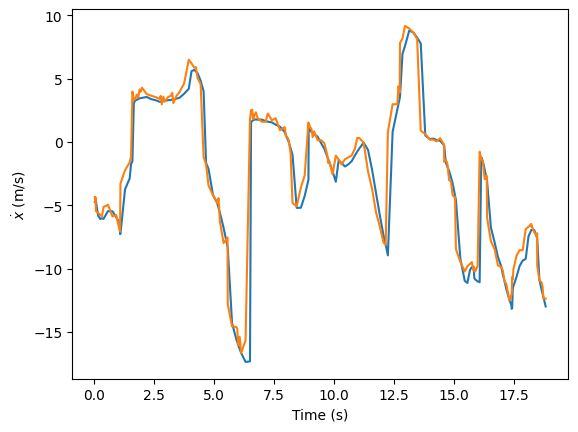

In [ ]:
plt.plot(time_array[:plt_idx], Xdot[0,:plt_idx],'-ko', label='Xdot True')
plt.plot(time_array[:plt_idx], Xdot_pred[0,:plt_idx],'-ro', label='Xdot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot{x}$ (m/s)')


Text(0, 0.5, '$\\dot{y}$ (m/s)')

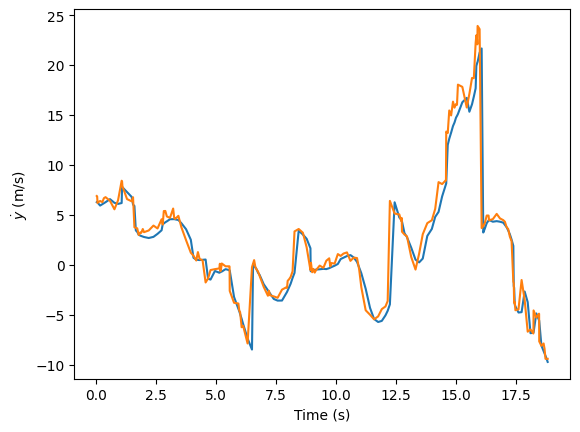

In [ ]:
plt.plot(time_array[:plt_idx], Ydot[0,:plt_idx],'-ko', label='Ydot True')
plt.plot(time_array[:plt_idx], Ydot_pred[0,:plt_idx],'-ro', label='Ydot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot{y}$ (m/s)')

Text(0, 0.5, '$\\dot{z}$ (m/s)')

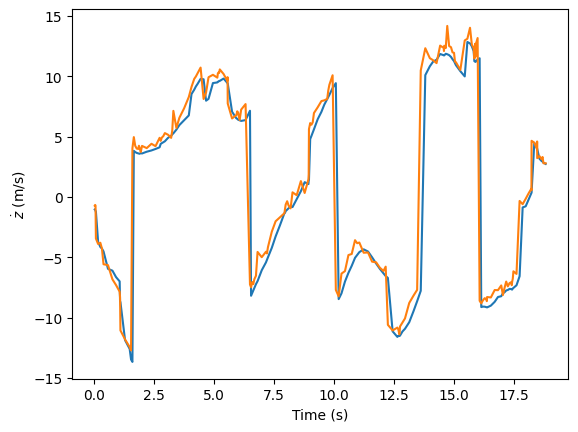

In [ ]:
plt.plot(time_array[:plt_idx], Zdot[0,:plt_idx], '-ko', label='Zdot True')
plt.plot(time_array[:plt_idx], Zdot_pred[0,:plt_idx], '-ro', label='Zdot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot{z}$ (m/s)')

Text(0, 0.5, '$\\ddot{x}$ (m/s²)')

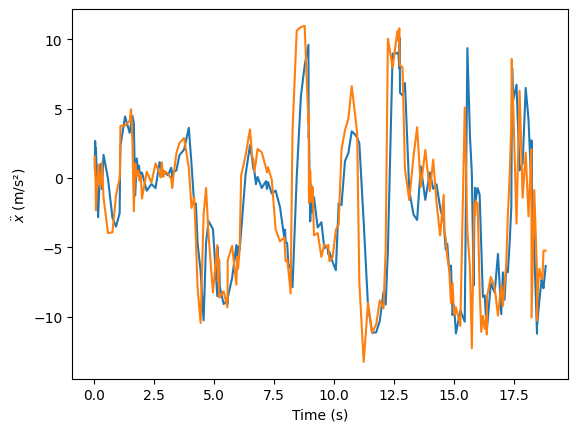

In [ ]:
plt.plot(time_array[:plt_idx], Xddot[0,:plt_idx], '-ko', label='Xddot True')
plt.plot(time_array[:plt_idx], Xddot_pred[0,:plt_idx], '-ro', label='Xddot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\ddot{x}$ (m/s²)')

Text(0, 0.5, '$\\ddot{y}$ (m/s²)')

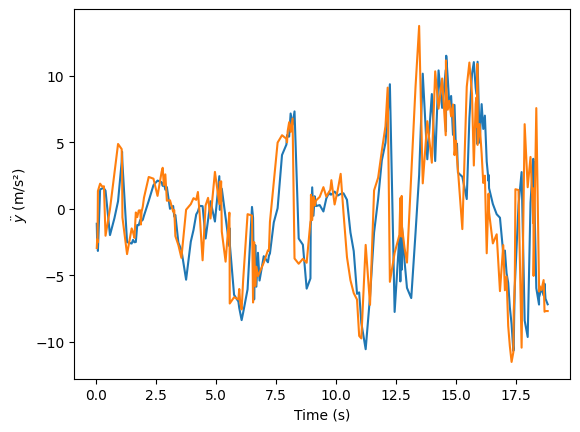

In [ ]:
plt.plot(time_array[:plt_idx], Yddot[0,:plt_idx], '-ko', label='Yddot True')
plt.plot(time_array[:plt_idx], Yddot_pred[0,:plt_idx], '-ro', label='Yddot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\ddot{y}$ (m/s²)')

Text(0, 0.5, '$\\ddot{z}$ (m/s²)')

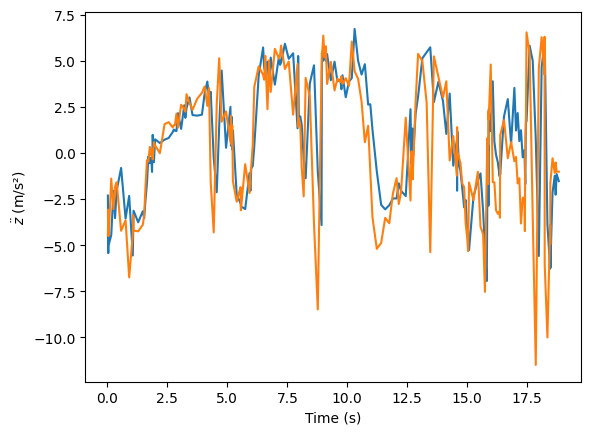

In [ ]:
plt.plot(time_array[:plt_idx], Zddot[0,:plt_idx], '-ko', label='Zddot True')
plt.plot(time_array[:plt_idx], Zddot_pred[0,:plt_idx], '-ro', label='Zddot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\ddot{z}$ (m/s²)')

Text(0, 0.5, '$\\omega_x$ (rad/s)')

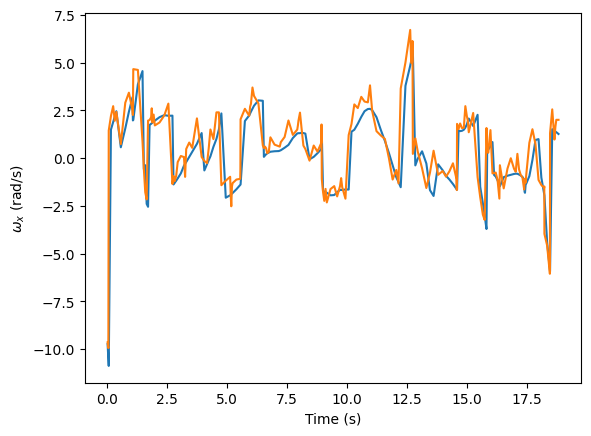

In [ ]:
plt.plot(time_array[:plt_idx], ωx[0,:plt_idx], '-ko', label='ωx True')
plt.plot(time_array[:plt_idx], ωx_pred[0,:plt_idx], '-ro', label='ωx Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_x$ (rad/s)')

Text(0, 0.5, '$\\omega_y$ (rad/s)')

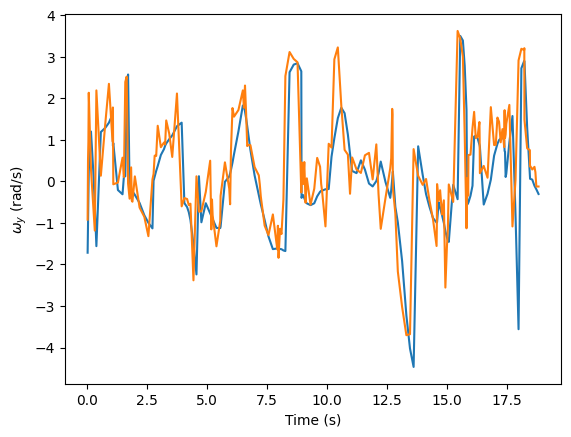

In [ ]:
plt.plot(time_array[:plt_idx], ωy[0,:plt_idx], '-ko', label='ωy True')
plt.plot(time_array[:plt_idx], ωy_pred[0,:plt_idx], '-ro', label='ωy Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_y$ (rad/s)')

Text(0, 0.5, '$\\omega_z$ (rad/s)')

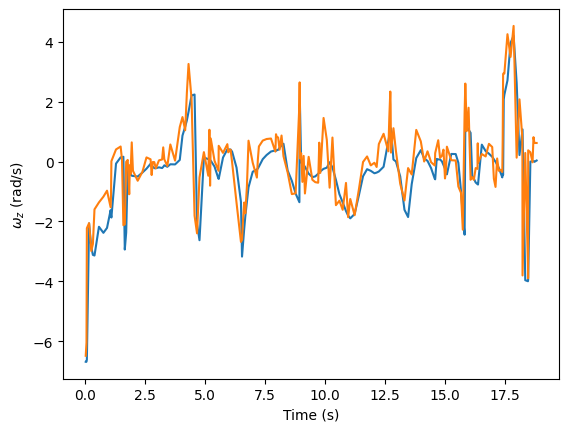

In [ ]:
plt.plot(time_array[:plt_idx], ωz[0,:plt_idx], '-ko', label='ωz True')
plt.plot(time_array[:plt_idx], ωz_pred[0,:plt_idx], '-ro', label='ωz Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_z$ (rad/s)')

Text(0, 0.5, '$\\dot{\\omega}_x$ (rad/s²)')

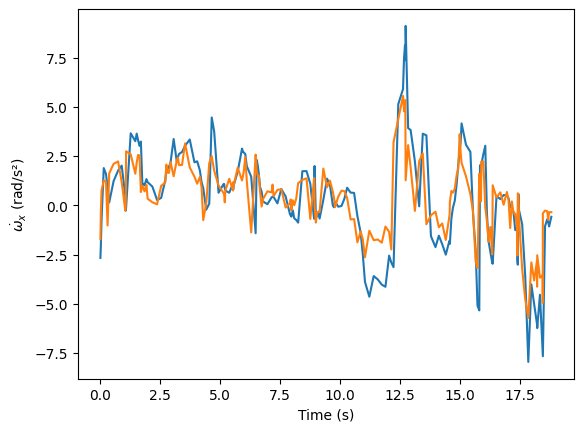

In [ ]:
plt.plot(time_array[:plt_idx], ωxdot[0,:plt_idx], '-ko', label='ωxdot True')
plt.plot(time_array[:plt_idx], ωxdot_pred[0,:plt_idx], '-ro', label='ωxdot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot{\omega}_x$ (rad/s²)')

Text(0, 0.5, '$\\dot{\\omega}_y$ (rad/s²)')

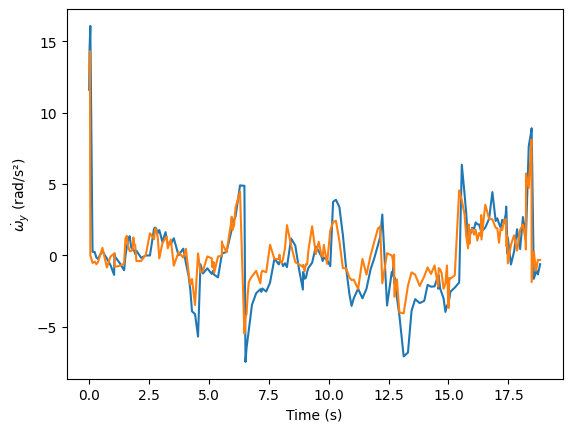

In [ ]:
plt.plot(time_array[:plt_idx],ωydot[0,:plt_idx], '-ko', label='ωydot True')
plt.plot(time_array[:plt_idx], ωydot_pred[0,:plt_idx], '-ro', label='ωydot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot{\omega}_y$ (rad/s²)')

Text(0, 0.5, '$\\dot{\\omega}_z$ (rad/s²)')

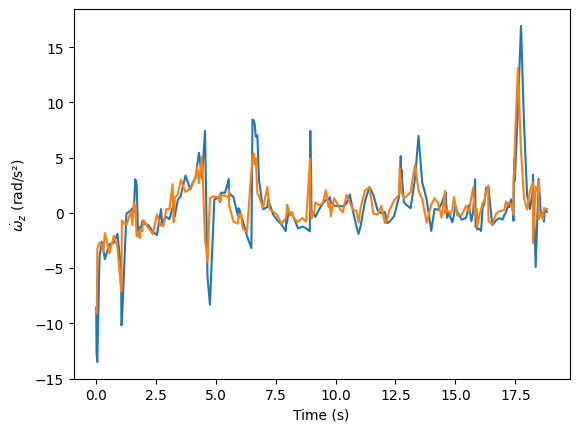

In [ ]:
plt.plot(time_array[:plt_idx], ωzdot[0,:plt_idx], '-ko', label='ωzdot True')
plt.plot(time_array[:plt_idx], ωzdot_pred[0,:plt_idx], '-ro', label='ωzdot Predicted')
plt.xlabel('Time (s)')
plt.ylabel(r'$\dot{\omega}_z$ (rad/s²)')